==== TASK 2: TIME SERIES DATA PREPARATION ====

Successfully loaded data from CSV.

Total Trading Days: 2888
Training Data (80%): 2015-01-02 to 2024-03-07 (2310 days)
Testing Data  (20%): 2024-03-08 to 2026-06-29 (578 days)


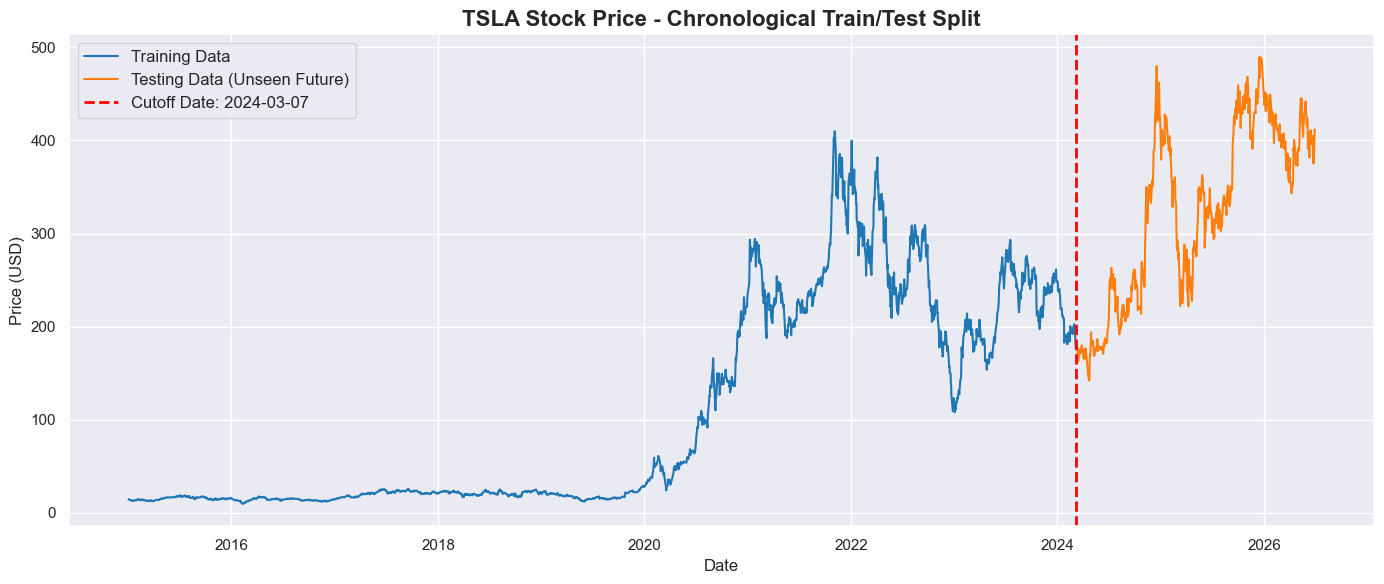

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# Set visual style
sns.set_theme(style="darkgrid")

print("==== TASK 2: TIME SERIES DATA PREPARATION ====\n")

# Since we are in a new notebook, we need to reload the data from Task 1.
try:
    # Try to load the CSV we saved earlier in the processed folder
    df_prices = pd.read_csv('../data/processed/asset_prices.csv', index_col=0, parse_dates=True)
    print("Successfully loaded data from CSV.")
    
    # Re-apply the time-based interpolation to handle any missing values
    df_prices_cleaned = df_prices.interpolate(method='time')
    tsla_prices = df_prices_cleaned['TSLA'].squeeze()

except FileNotFoundError:
    # FALLBACK: If the CSV isn't found, fetch ONLY Tesla data to avoid yfinance MultiIndex errors!
    print("CSV not found. Downloading fresh TSLA data from Yahoo Finance...")
    df_prices = yf.download('TSLA', start='2015-01-01', end='2024-12-31')
    
    # Recent yfinance updates sometimes drop 'Adj Close' or change column structures.
    # We will safely use 'Close' if 'Adj Close' is missing.
    if 'Adj Close' in df_prices.columns:
        tsla_prices = df_prices['Adj Close'].interpolate(method='time').squeeze()
    else:
        tsla_prices = df_prices['Close'].interpolate(method='time').squeeze()

# Determine the exact row index for an 80% / 20% split
split_idx = int(len(tsla_prices) * 0.8)

# CRITICAL: Split chronologically using index slicing (no random shuffling!)
train_tsla = tsla_prices.iloc[:split_idx]
test_tsla = tsla_prices.iloc[split_idx:]

# Print the date ranges to verify the chronological split
print(f"\nTotal Trading Days: {len(tsla_prices)}")
print(f"Training Data (80%): {train_tsla.index[0].date()} to {train_tsla.index[-1].date()} ({len(train_tsla)} days)")
print(f"Testing Data  (20%): {test_tsla.index[0].date()} to {test_tsla.index[-1].date()} ({len(test_tsla)} days)")

# ==========================================
# Visualize the Train-Test Split
# ==========================================
plt.figure(figsize=(14, 6))

# Plot training data in blue
plt.plot(train_tsla.index, train_tsla, label='Training Data', color='#1f77b4', linewidth=1.5)

# Plot testing data in orange
plt.plot(test_tsla.index, test_tsla, label='Testing Data (Unseen Future)', color='#ff7f0e', linewidth=1.5)

# Add a vertical dashed line to mark the exact cutoff point
cutoff_date = train_tsla.index[-1]
plt.axvline(x=cutoff_date, color='red', linestyle='--', linewidth=2, 
            label=f'Cutoff Date: {cutoff_date.date()}')

plt.title('TSLA Stock Price - Chronological Train/Test Split', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

==== TASK 2: TIME SERIES DATA PREPARATION ====

Successfully loaded data from CSV.

Total Trading Days: 2888
Training Data (80%): 2015-01-02 to 2024-03-07 (2310 days)
Testing Data  (20%): 2024-03-08 to 2026-06-29 (578 days)


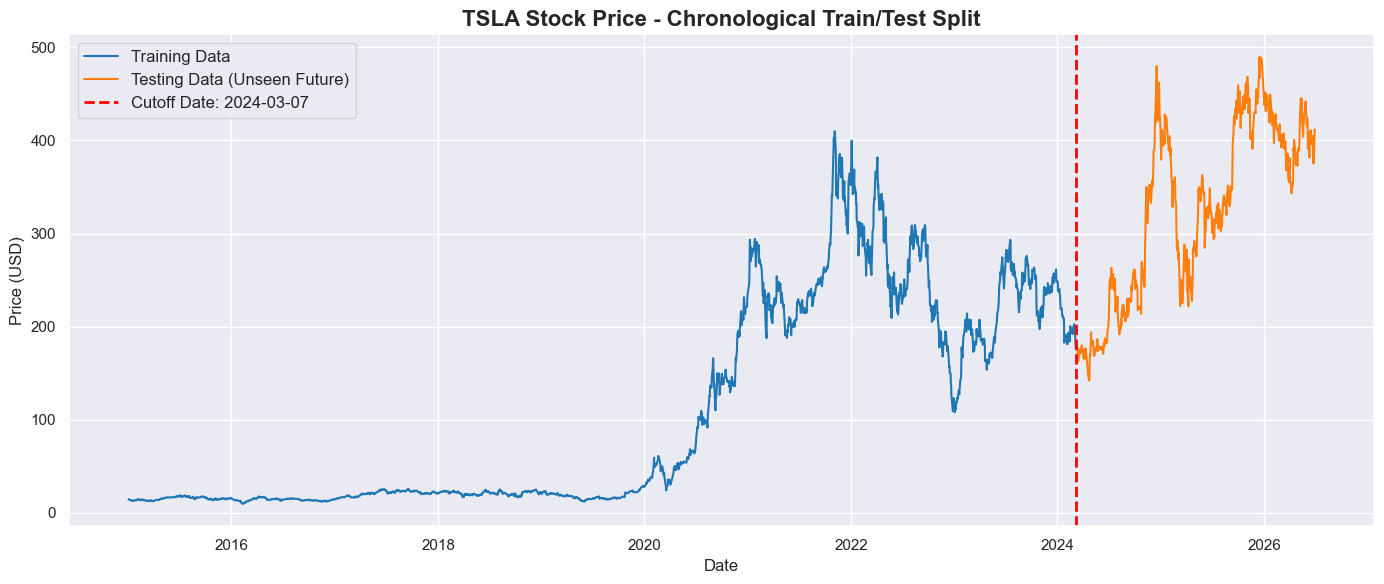


==== ARIMA MODELING: ACF & PACF PLOTS ====


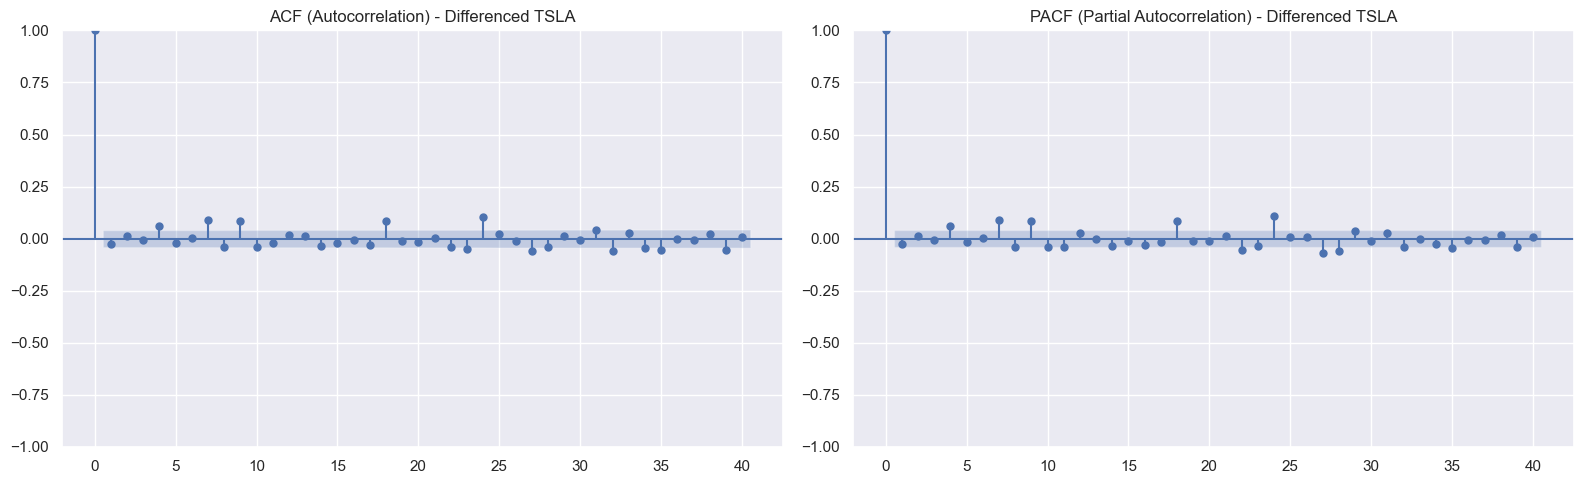


==== RUNNING AUTO ARIMA ====
Searching for the best (p,d,q) parameters based on AIC score...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=14610.010, Time=0.32 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=14610.292, Time=0.23 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=14610.329, Time=0.67 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=14608.366, Time=0.11 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=14610.926, Time=1.61 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 2.954 seconds

--- Best ARIMA Model Found ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2310
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -7303.183
Date:                Wed, 08 Jul 2026   AIC                          14608.366
Time:                        00:07:53   BIC                          14614.110
Sample:                 

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


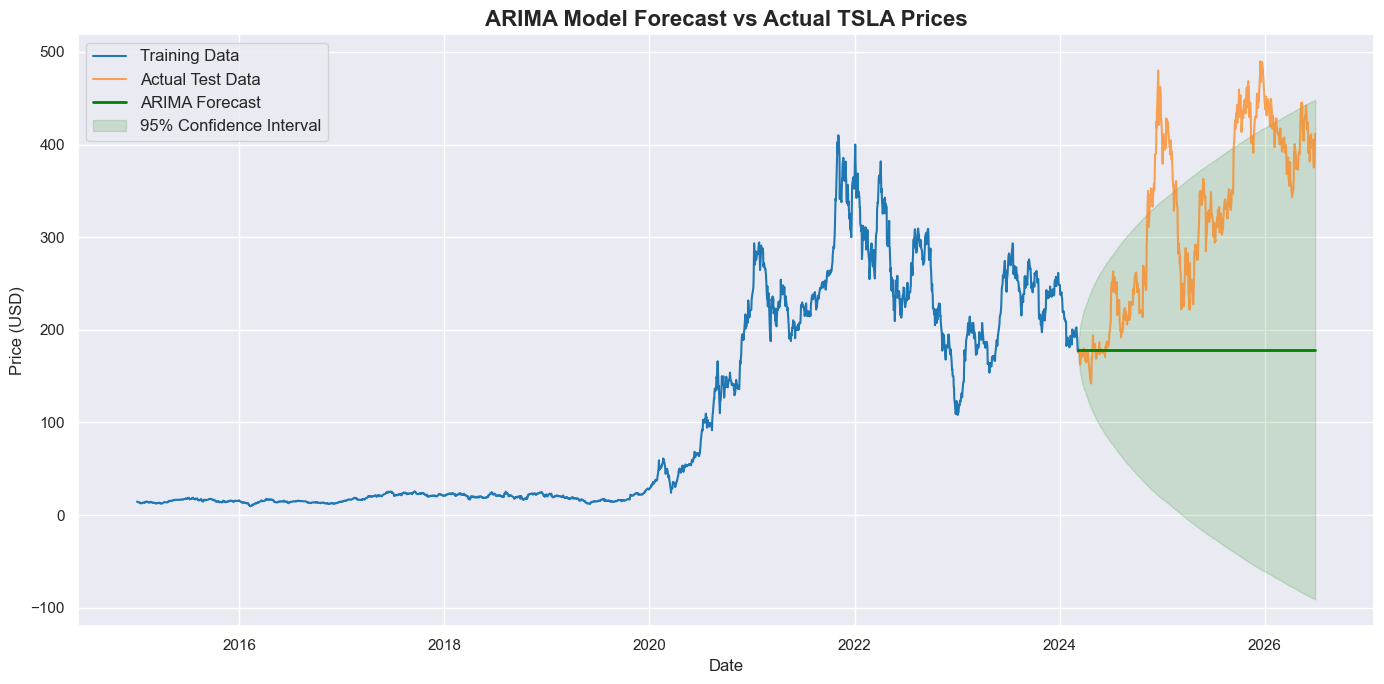

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# Set visual style
sns.set_theme(style="darkgrid")

print("==== TASK 2: TIME SERIES DATA PREPARATION ====\n")

# Since we are in a new notebook, we need to reload the data from Task 1.
try:
    # Try to load the CSV we saved earlier in the processed folder
    df_prices = pd.read_csv('../data/processed/asset_prices.csv', index_col=0, parse_dates=True)
    print("Successfully loaded data from CSV.")
    
    # Re-apply the time-based interpolation to handle any missing values
    df_prices_cleaned = df_prices.interpolate(method='time')
    tsla_prices = df_prices_cleaned['TSLA'].squeeze()

except FileNotFoundError:
    # FALLBACK: If the CSV isn't found, fetch ONLY Tesla data to avoid yfinance MultiIndex errors!
    print("CSV not found. Downloading fresh TSLA data from Yahoo Finance...")
    df_prices = yf.download('TSLA', start='2015-01-01', end='2024-12-31')
    
    # Recent yfinance updates sometimes drop 'Adj Close' or change column structures.
    # We will safely use 'Close' if 'Adj Close' is missing.
    if 'Adj Close' in df_prices.columns:
        tsla_prices = df_prices['Adj Close'].interpolate(method='time').squeeze()
    else:
        tsla_prices = df_prices['Close'].interpolate(method='time').squeeze()

# Determine the exact row index for an 80% / 20% split
split_idx = int(len(tsla_prices) * 0.8)

# CRITICAL: Split chronologically using index slicing (no random shuffling!)
train_tsla = tsla_prices.iloc[:split_idx]
test_tsla = tsla_prices.iloc[split_idx:]

# Print the date ranges to verify the chronological split
print(f"\nTotal Trading Days: {len(tsla_prices)}")
print(f"Training Data (80%): {train_tsla.index[0].date()} to {train_tsla.index[-1].date()} ({len(train_tsla)} days)")
print(f"Testing Data  (20%): {test_tsla.index[0].date()} to {test_tsla.index[-1].date()} ({len(test_tsla)} days)")

# ==========================================
# Visualize the Train-Test Split
# ==========================================
plt.figure(figsize=(14, 6))

# Plot training data in blue
plt.plot(train_tsla.index, train_tsla, label='Training Data', color='#1f77b4', linewidth=1.5)

# Plot testing data in orange
plt.plot(test_tsla.index, test_tsla, label='Testing Data (Unseen Future)', color='#ff7f0e', linewidth=1.5)

# Add a vertical dashed line to mark the exact cutoff point
cutoff_date = train_tsla.index[-1]
plt.axvline(x=cutoff_date, color='red', linestyle='--', linewidth=2, 
            label=f'Cutoff Date: {cutoff_date.date()}')

plt.title('TSLA Stock Price - Chronological Train/Test Split', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# ACF / PACF Plots for Parameter Estimation
# ==========================================
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("\n==== ARIMA MODELING: ACF & PACF PLOTS ====")
# We difference the training data once (d=1) because we proved it was non-stationary in Task 1.
train_diff = train_tsla.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# ACF helps determine the 'q' (Moving Average) term
plot_acf(train_diff, ax=axes[0], lags=40, title='ACF (Autocorrelation) - Differenced TSLA')
# PACF helps determine the 'p' (AutoRegressive) term
plot_pacf(train_diff, ax=axes[1], lags=40, title='PACF (Partial Autocorrelation) - Differenced TSLA')
plt.tight_layout()
plt.show()

# ==========================================
# Auto ARIMA Model (Parameter Search & Fitting)
# ==========================================
from pmdarima import auto_arima

print("\n==== RUNNING AUTO ARIMA ====")
print("Searching for the best (p,d,q) parameters based on AIC score...")
# NOTE ON SARIMA: Daily stock prices rarely exhibit true, predictable seasonality 
# (like retail sales in December). Therefore, we set seasonal=False. 
# If modelling seasonal data, you would use seasonal=True and m=5 (weekly) or m=21 (monthly).

model_auto = auto_arima(
    train_tsla, 
    start_p=0, start_q=0, 
    max_p=5, max_q=5, 
    d=1,                      # We know d=1 from our ADF stationarity test
    seasonal=False,           # No strict seasonality in daily stocks
    trace=True,               # Prints out the models it tries
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True             # Uses a smart search algorithm to save time
)

print("\n--- Best ARIMA Model Found ---")
print(model_auto.summary())

# ==========================================
# Forecasting the Test Period
# ==========================================
print("\n==== GENERATING FORECASTS ====")
# Predict the exact number of steps into the future as our test dataset length
forecast_steps = len(test_tsla)
# return_conf_int=True gives us the upper and lower bounds of the prediction
forecast, conf_int = model_auto.predict(n_periods=forecast_steps, return_conf_int=True)

# Convert forecast arrays into pandas Series and assign the actual future dates to them
forecast_series = pd.Series(forecast.values, index=test_tsla.index)
lower_bound = pd.Series(conf_int[:, 0], index=test_tsla.index)
upper_bound = pd.Series(conf_int[:, 1], index=test_tsla.index)

# ==========================================
# Visualize the Forecast vs Actual
# ==========================================
plt.figure(figsize=(14, 7))
plt.plot(train_tsla.index, train_tsla, label='Training Data', color='#1f77b4')
plt.plot(test_tsla.index, test_tsla, label='Actual Test Data', color='#ff7f0e', alpha=0.7)
plt.plot(forecast_series.index, forecast_series, label='ARIMA Forecast', color='green', linewidth=2)

# Fill the confidence interval
plt.fill_between(lower_bound.index, lower_bound, upper_bound, color='green', alpha=0.15, label='95% Confidence Interval')

plt.title(f'ARIMA Model Forecast vs Actual TSLA Prices', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

==== TASK 2: TIME SERIES DATA PREPARATION ====

Successfully loaded data from CSV.

Total Trading Days: 2888
Training Data (80%): 2015-01-02 to 2024-03-07 (2310 days)
Testing Data  (20%): 2024-03-08 to 2026-06-29 (578 days)


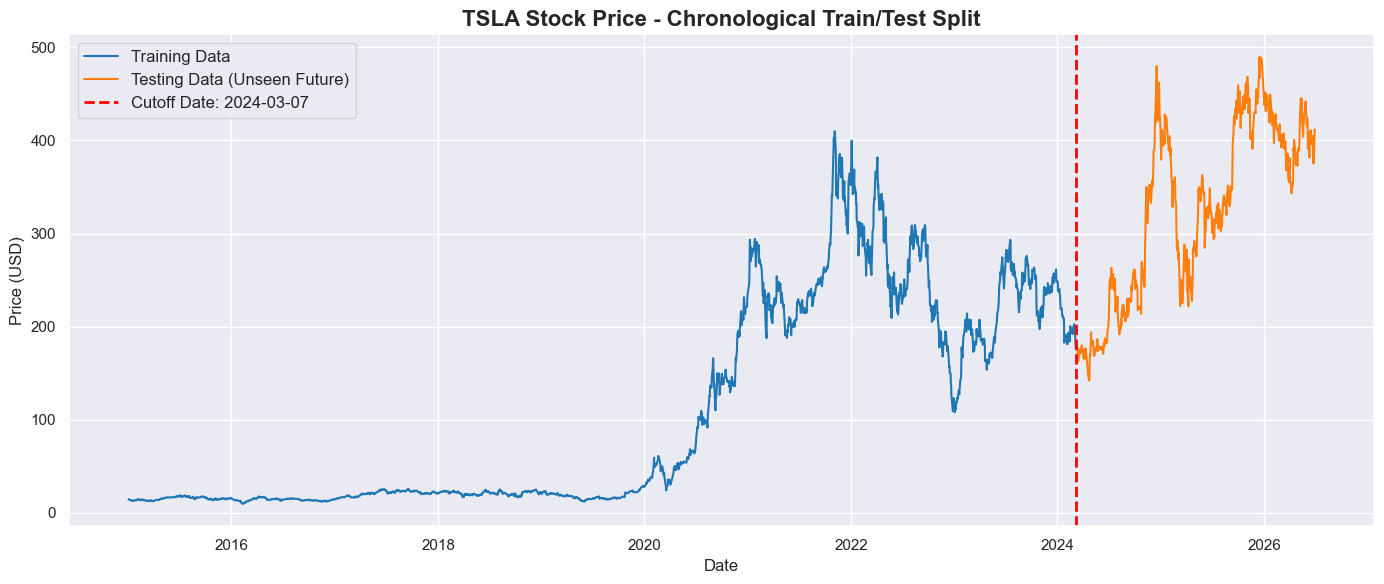


==== ARIMA MODELING: ACF & PACF PLOTS ====


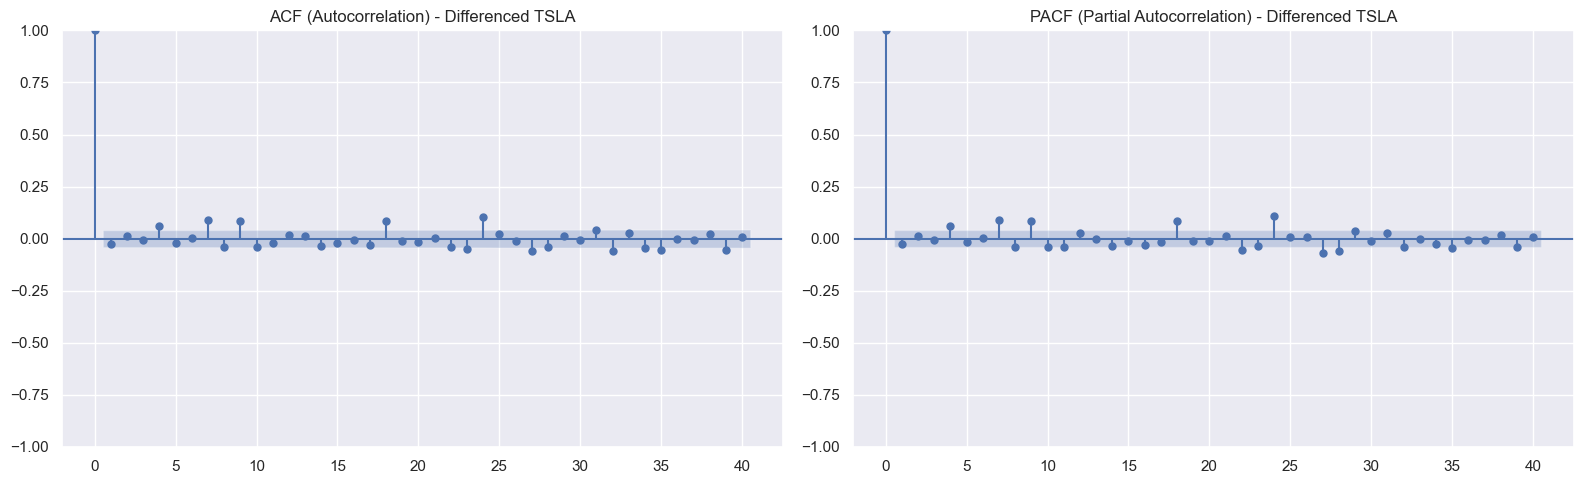


==== RUNNING AUTO ARIMA ====
Searching for the best (p,d,q) parameters based on AIC score...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=14610.010, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=14610.292, Time=0.22 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=14610.329, Time=0.30 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=14608.366, Time=0.07 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=14610.926, Time=1.22 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.897 seconds

--- Best ARIMA Model Found ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2310
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -7303.183
Date:                Wed, 08 Jul 2026   AIC                          14608.366
Time:                        00:10:26   BIC                          14614.110
Sample:                 

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


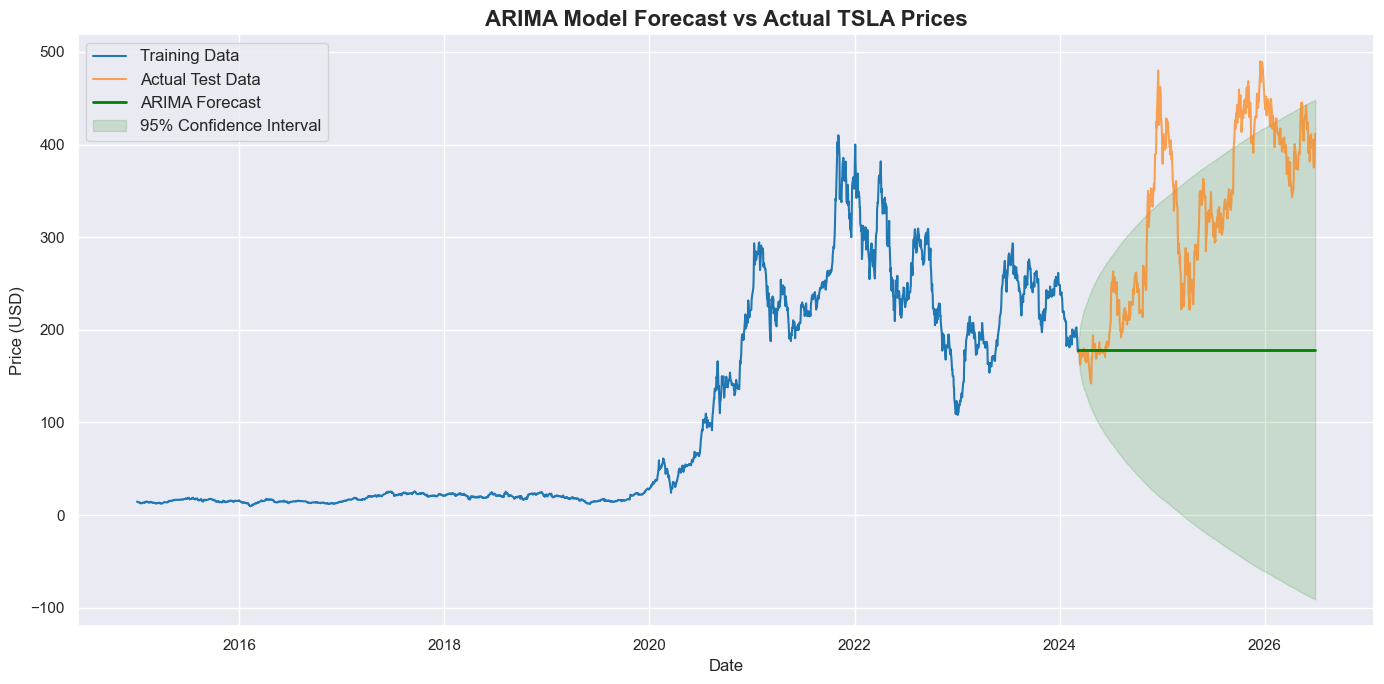


==== RUNNING LSTM MODEL ====


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Training LSTM network (this may take a moment depending on your CPU/GPU)...
Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.0173
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 5.6534e-04
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 5.5511e-04
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 4.9694e-04
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 4.4288e-04
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 4.0781e-04
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 3.5787e-04
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 4.5237e-04
Epoch 9/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 3.2485e-04
Epoch 10/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 3.5248e-04
Generating test predictions...
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step


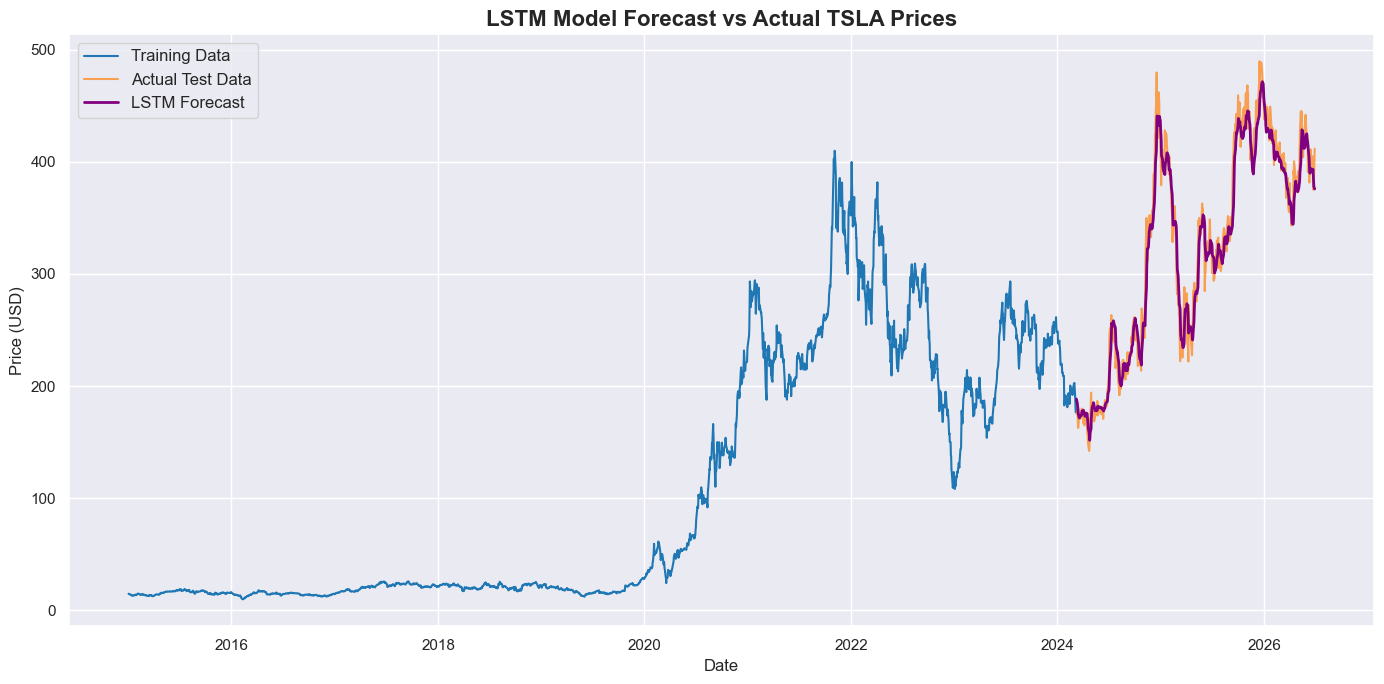

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import numpy as np

# Set visual style
sns.set_theme(style="darkgrid")

print("==== TASK 2: TIME SERIES DATA PREPARATION ====\n")

# Since we are in a new notebook, we need to reload the data from Task 1.
try:
    # Try to load the CSV we saved earlier in the processed folder
    df_prices = pd.read_csv('../data/processed/asset_prices.csv', index_col=0, parse_dates=True)
    print("Successfully loaded data from CSV.")
    
    # Re-apply the time-based interpolation to handle any missing values
    df_prices_cleaned = df_prices.interpolate(method='time')
    tsla_prices = df_prices_cleaned['TSLA'].squeeze()

except FileNotFoundError:
    # FALLBACK: If the CSV isn't found, fetch ONLY Tesla data to avoid yfinance MultiIndex errors!
    print("CSV not found. Downloading fresh TSLA data from Yahoo Finance...")
    df_prices = yf.download('TSLA', start='2015-01-01', end='2024-12-31')
    
    # Recent yfinance updates sometimes drop 'Adj Close' or change column structures.
    # We will safely use 'Close' if 'Adj Close' is missing.
    if 'Adj Close' in df_prices.columns:
        tsla_prices = df_prices['Adj Close'].interpolate(method='time').squeeze()
    else:
        tsla_prices = df_prices['Close'].interpolate(method='time').squeeze()

# Determine the exact row index for an 80% / 20% split
split_idx = int(len(tsla_prices) * 0.8)

# CRITICAL: Split chronologically using index slicing (no random shuffling!)
train_tsla = tsla_prices.iloc[:split_idx]
test_tsla = tsla_prices.iloc[split_idx:]

# Print the date ranges to verify the chronological split
print(f"\nTotal Trading Days: {len(tsla_prices)}")
print(f"Training Data (80%): {train_tsla.index[0].date()} to {train_tsla.index[-1].date()} ({len(train_tsla)} days)")
print(f"Testing Data  (20%): {test_tsla.index[0].date()} to {test_tsla.index[-1].date()} ({len(test_tsla)} days)")

# ==========================================
# Visualize the Train-Test Split
# ==========================================
plt.figure(figsize=(14, 6))

# Plot training data in blue
plt.plot(train_tsla.index, train_tsla, label='Training Data', color='#1f77b4', linewidth=1.5)

# Plot testing data in orange
plt.plot(test_tsla.index, test_tsla, label='Testing Data (Unseen Future)', color='#ff7f0e', linewidth=1.5)

# Add a vertical dashed line to mark the exact cutoff point
cutoff_date = train_tsla.index[-1]
plt.axvline(x=cutoff_date, color='red', linestyle='--', linewidth=2, 
            label=f'Cutoff Date: {cutoff_date.date()}')

plt.title('TSLA Stock Price - Chronological Train/Test Split', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# ACF / PACF Plots for Parameter Estimation
# ==========================================
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("\n==== ARIMA MODELING: ACF & PACF PLOTS ====")
# We difference the training data once (d=1) because we proved it was non-stationary in Task 1.
train_diff = train_tsla.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# ACF helps determine the 'q' (Moving Average) term
plot_acf(train_diff, ax=axes[0], lags=40, title='ACF (Autocorrelation) - Differenced TSLA')
# PACF helps determine the 'p' (AutoRegressive) term
plot_pacf(train_diff, ax=axes[1], lags=40, title='PACF (Partial Autocorrelation) - Differenced TSLA')
plt.tight_layout()
plt.show()

# ==========================================
# Auto ARIMA Model (Parameter Search & Fitting)
# ==========================================
from pmdarima import auto_arima

print("\n==== RUNNING AUTO ARIMA ====")
print("Searching for the best (p,d,q) parameters based on AIC score...")
# NOTE ON SARIMA: Daily stock prices rarely exhibit true, predictable seasonality 
# (like retail sales in December). Therefore, we set seasonal=False. 
# If modelling seasonal data, you would use seasonal=True and m=5 (weekly) or m=21 (monthly).

model_auto = auto_arima(
    train_tsla, 
    start_p=0, start_q=0, 
    max_p=5, max_q=5, 
    d=1,                      # We know d=1 from our ADF stationarity test
    seasonal=False,           # No strict seasonality in daily stocks
    trace=True,               # Prints out the models it tries
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True             # Uses a smart search algorithm to save time
)

print("\n--- Best ARIMA Model Found ---")
print(model_auto.summary())

# ==========================================
# Forecasting the Test Period
# ==========================================
print("\n==== GENERATING FORECASTS ====")
# Predict the exact number of steps into the future as our test dataset length
forecast_steps = len(test_tsla)
# return_conf_int=True gives us the upper and lower bounds of the prediction
forecast, conf_int = model_auto.predict(n_periods=forecast_steps, return_conf_int=True)

# Convert forecast arrays into pandas Series and assign the actual future dates to them
forecast_series = pd.Series(forecast.values, index=test_tsla.index)
lower_bound = pd.Series(conf_int[:, 0], index=test_tsla.index)
upper_bound = pd.Series(conf_int[:, 1], index=test_tsla.index)

# ==========================================
# Visualize the Forecast vs Actual
# ==========================================
plt.figure(figsize=(14, 7))
plt.plot(train_tsla.index, train_tsla, label='Training Data', color='#1f77b4')
plt.plot(test_tsla.index, test_tsla, label='Actual Test Data', color='#ff7f0e', alpha=0.7)
plt.plot(forecast_series.index, forecast_series, label='ARIMA Forecast', color='green', linewidth=2)

# Fill the confidence interval
plt.fill_between(lower_bound.index, lower_bound, upper_bound, color='green', alpha=0.15, label='95% Confidence Interval')

plt.title('ARIMA Model Forecast vs Actual TSLA Prices', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# DEEP LEARNING: LSTM MODELING
# ==========================================
print("\n==== RUNNING LSTM MODEL ====")
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input

# 1. Scale Data (Neural Networks are highly sensitive to unscaled data)
scaler = MinMaxScaler(feature_range=(0, 1))
# We reshape to (-1, 1) to convert the pandas series into a 2D array expected by the scaler
scaled_data = scaler.fit_transform(tsla_prices.values.reshape(-1, 1))

# Split the scaled data using the exact same split index as ARIMA
train_scaled = scaled_data[:split_idx]
test_scaled = scaled_data[split_idx:]

# 2. Prepare Sequence Data
window_size = 60 # Use the last 60 days to predict the next 1 day

def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, window_size)

# Reshape X_train for LSTM [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# 3. Build LSTM Architecture
model_lstm = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    LSTM(units=50, return_sequences=False),
    Dense(units=25),
    Dense(units=1) # Output layer (predicting 1 value)
])

model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# 4. Train the Model
print("Training LSTM network (this may take a moment depending on your CPU/GPU)...")
# Epochs=10 and batch_size=32 is a good balance for rapid prototyping
model_lstm.fit(X_train, y_train, batch_size=32, epochs=10, verbose=1)

# 5. Prepare Test Sequence for Forecasting
# To predict the first day of the test set, we need the last 60 days of the training set.
# So we slice the combined scaled_data array accordingly.
inputs = scaled_data[split_idx - window_size:]

X_test = []
for i in range(window_size, len(inputs)):
    X_test.append(inputs[i-window_size:i, 0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# 6. Generate Forecasts
print("Generating test predictions...")
predicted_prices_scaled = model_lstm.predict(X_test)
# Inverse transform the predictions back to real dollar values
predicted_prices = scaler.inverse_transform(predicted_prices_scaled)

# Convert to pandas series for easy plotting
lstm_forecast_series = pd.Series(predicted_prices[:, 0], index=test_tsla.index)

# 7. Visualize LSTM Forecast
plt.figure(figsize=(14, 7))
plt.plot(train_tsla.index, train_tsla, label='Training Data', color='#1f77b4')
plt.plot(test_tsla.index, test_tsla, label='Actual Test Data', color='#ff7f0e', alpha=0.7)
plt.plot(lstm_forecast_series.index, lstm_forecast_series, label='LSTM Forecast', color='purple', linewidth=2)

plt.title('LSTM Model Forecast vs Actual TSLA Prices', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

==== TASK 2: TIME SERIES DATA PREPARATION ====

Successfully loaded data from CSV.

Total Trading Days: 2888
Training Data (80%): 2015-01-02 to 2024-03-07 (2310 days)
Testing Data  (20%): 2024-03-08 to 2026-06-29 (578 days)


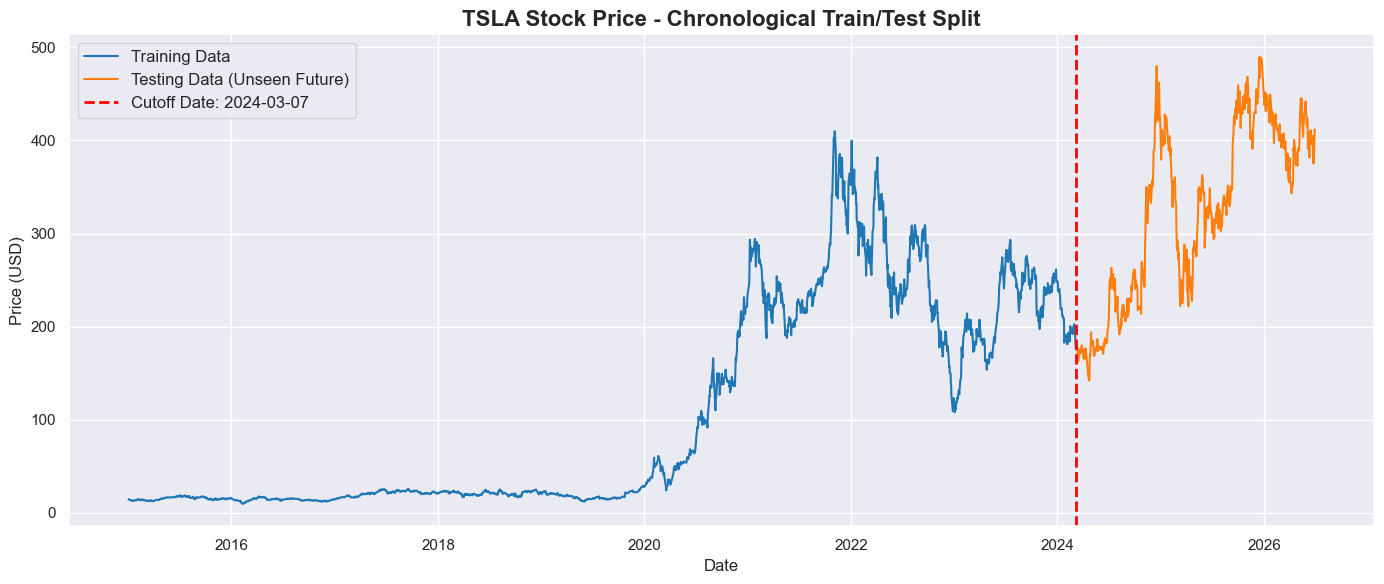


==== ARIMA MODELING: ACF & PACF PLOTS ====


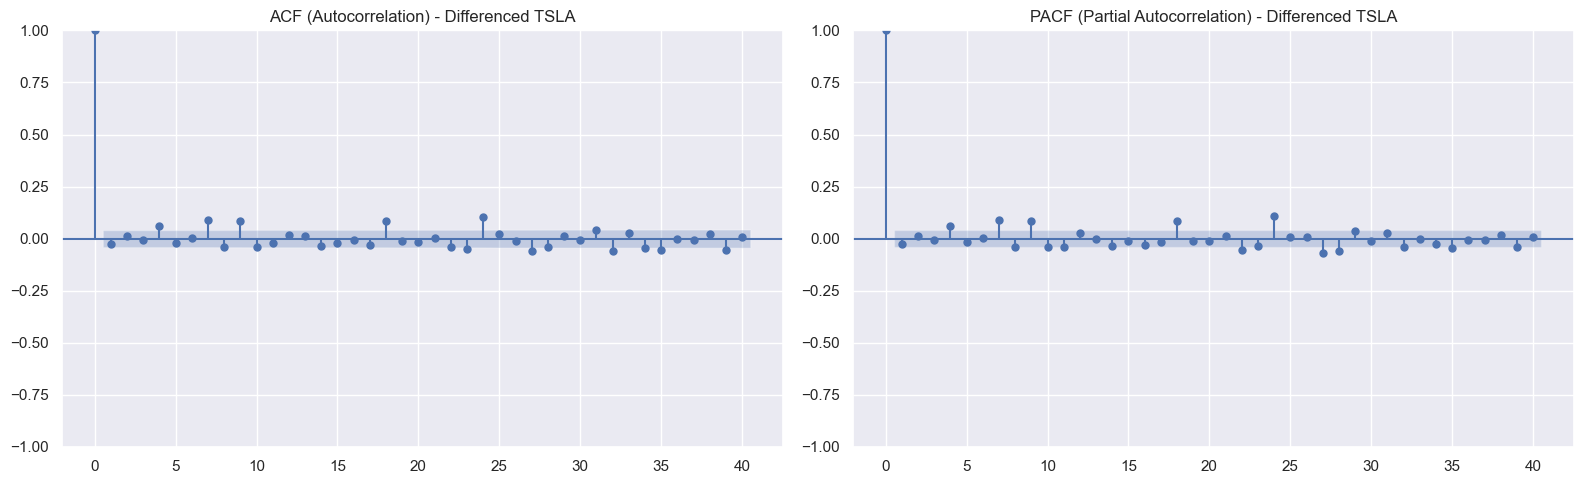


==== RUNNING AUTO ARIMA ====
Searching for the best (p,d,q) parameters based on AIC score...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=14610.010, Time=0.15 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=14610.292, Time=0.42 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=14610.329, Time=0.61 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=14608.366, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=14610.926, Time=1.61 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 2.874 seconds

--- Best ARIMA Model Found ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2310
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -7303.183
Date:                Wed, 08 Jul 2026   AIC                          14608.366
Time:                        00:14:19   BIC                          14614.110
Sample:                 

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


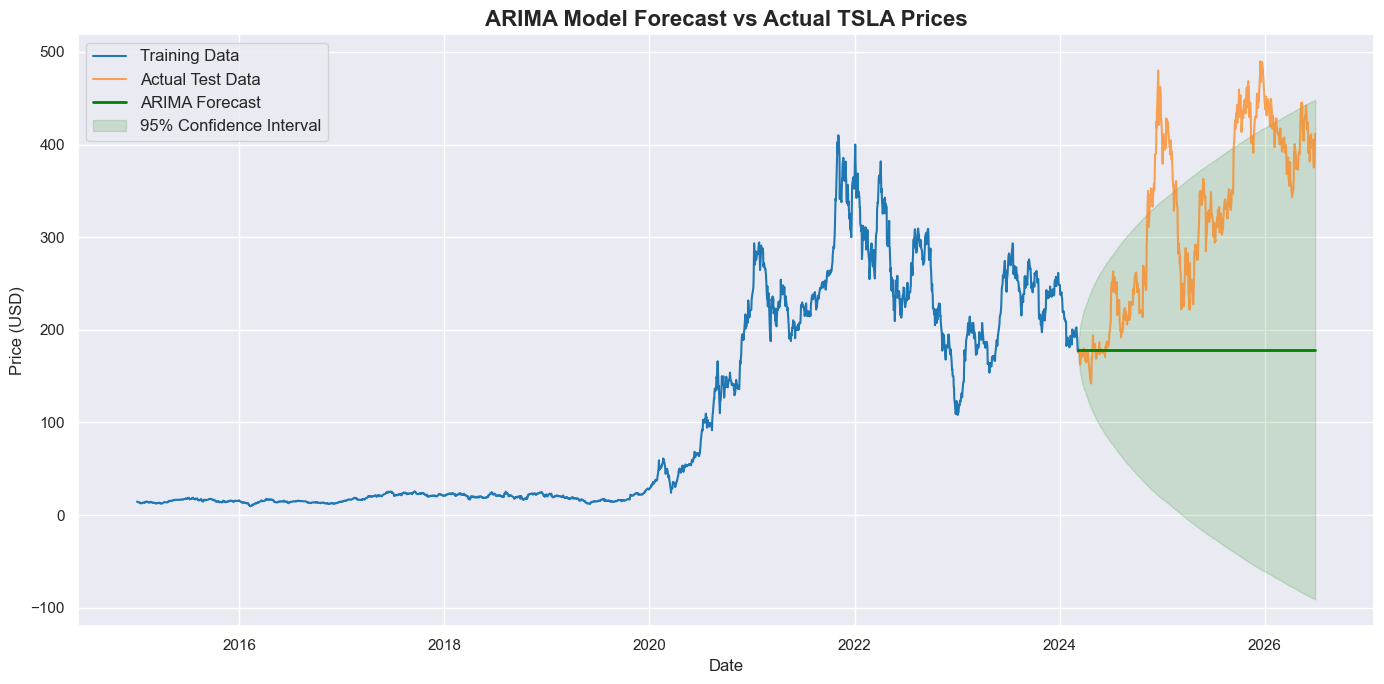


==== RUNNING LSTM MODEL ====
Training optimized LSTM network...
Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 228ms/step - loss: 0.0199 - val_loss: 0.0023
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 170ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - loss: 0.0012 - val_loss: 0.0017
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.0010 - val_loss: 0.0011
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - loss: 0.0011 - val_loss: 8.6760e-04
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - loss: 0.0011 - val_loss: 8.0684e-04
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - loss: 9.6401e-04 - val_loss: 0.0016
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - loss: 0.0011 - val_loss: 7.4171e-04
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - loss: 8.0143e-04 - val_loss: 6.7316e-04
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/s

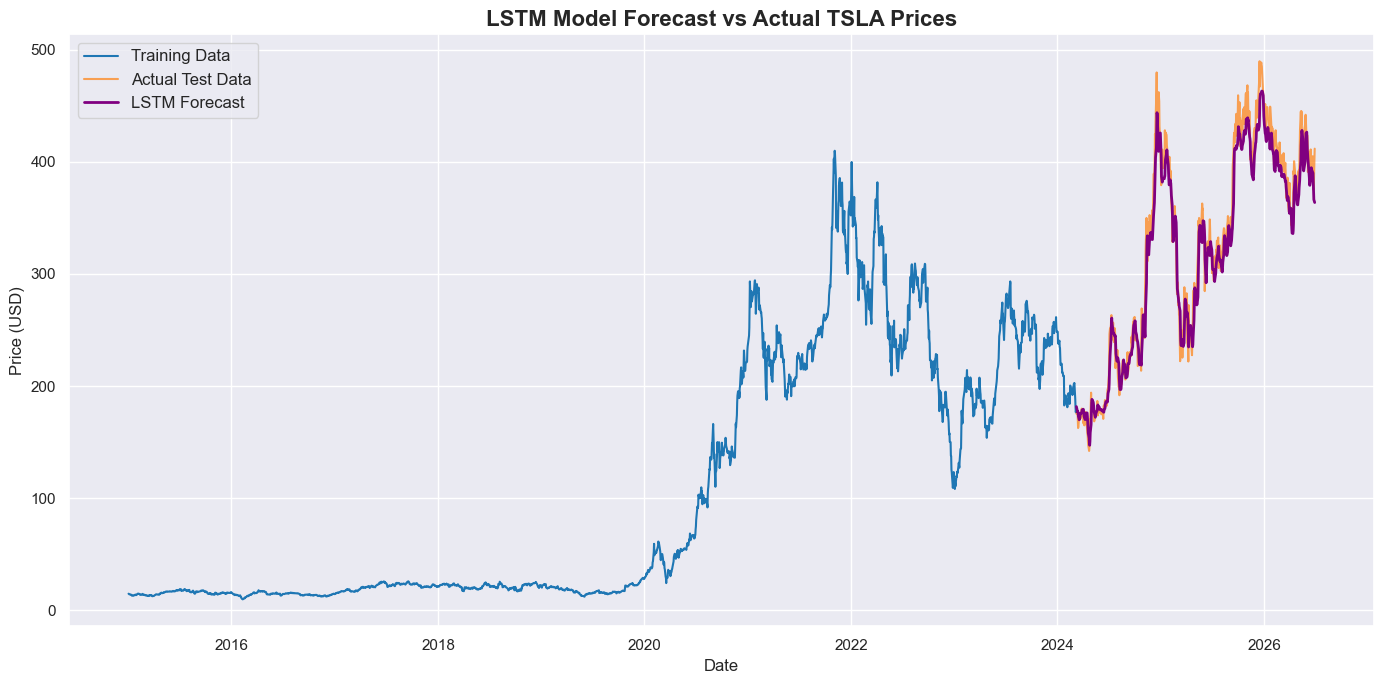

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import numpy as np

# Set visual style
sns.set_theme(style="darkgrid")

print("==== TASK 2: TIME SERIES DATA PREPARATION ====\n")

# Since we are in a new notebook, we need to reload the data from Task 1.
try:
    # Try to load the CSV we saved earlier in the processed folder
    df_prices = pd.read_csv('../data/processed/asset_prices.csv', index_col=0, parse_dates=True)
    print("Successfully loaded data from CSV.")
    
    # Re-apply the time-based interpolation to handle any missing values
    df_prices_cleaned = df_prices.interpolate(method='time')
    tsla_prices = df_prices_cleaned['TSLA'].squeeze()

except FileNotFoundError:
    # FALLBACK: If the CSV isn't found, fetch ONLY Tesla data to avoid yfinance MultiIndex errors!
    print("CSV not found. Downloading fresh TSLA data from Yahoo Finance...")
    df_prices = yf.download('TSLA', start='2015-01-01', end='2024-12-31')
    
    # Recent yfinance updates sometimes drop 'Adj Close' or change column structures.
    # We will safely use 'Close' if 'Adj Close' is missing.
    if 'Adj Close' in df_prices.columns:
        tsla_prices = df_prices['Adj Close'].interpolate(method='time').squeeze()
    else:
        tsla_prices = df_prices['Close'].interpolate(method='time').squeeze()

# Determine the exact row index for an 80% / 20% split
split_idx = int(len(tsla_prices) * 0.8)

# CRITICAL: Split chronologically using index slicing (no random shuffling!)
train_tsla = tsla_prices.iloc[:split_idx]
test_tsla = tsla_prices.iloc[split_idx:]

# Print the date ranges to verify the chronological split
print(f"\nTotal Trading Days: {len(tsla_prices)}")
print(f"Training Data (80%): {train_tsla.index[0].date()} to {train_tsla.index[-1].date()} ({len(train_tsla)} days)")
print(f"Testing Data  (20%): {test_tsla.index[0].date()} to {test_tsla.index[-1].date()} ({len(test_tsla)} days)")

# ==========================================
# Visualize the Train-Test Split
# ==========================================
plt.figure(figsize=(14, 6))

# Plot training data in blue
plt.plot(train_tsla.index, train_tsla, label='Training Data', color='#1f77b4', linewidth=1.5)

# Plot testing data in orange
plt.plot(test_tsla.index, test_tsla, label='Testing Data (Unseen Future)', color='#ff7f0e', linewidth=1.5)

# Add a vertical dashed line to mark the exact cutoff point
cutoff_date = train_tsla.index[-1]
plt.axvline(x=cutoff_date, color='red', linestyle='--', linewidth=2, 
            label=f'Cutoff Date: {cutoff_date.date()}')

plt.title('TSLA Stock Price - Chronological Train/Test Split', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# ACF / PACF Plots for Parameter Estimation
# ==========================================
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("\n==== ARIMA MODELING: ACF & PACF PLOTS ====")
# We difference the training data once (d=1) because we proved it was non-stationary in Task 1.
train_diff = train_tsla.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# ACF helps determine the 'q' (Moving Average) term
plot_acf(train_diff, ax=axes[0], lags=40, title='ACF (Autocorrelation) - Differenced TSLA')
# PACF helps determine the 'p' (AutoRegressive) term
plot_pacf(train_diff, ax=axes[1], lags=40, title='PACF (Partial Autocorrelation) - Differenced TSLA')
plt.tight_layout()
plt.show()

# ==========================================
# Auto ARIMA Model (Parameter Search & Fitting)
# ==========================================
from pmdarima import auto_arima

print("\n==== RUNNING AUTO ARIMA ====")
print("Searching for the best (p,d,q) parameters based on AIC score...")
# NOTE ON SARIMA: Daily stock prices rarely exhibit true, predictable seasonality 
# (like retail sales in December). Therefore, we set seasonal=False. 
# If modelling seasonal data, you would use seasonal=True and m=5 (weekly) or m=21 (monthly).

# OPTIMIZATION NOTE: stepwise=True uses a smart, fast search algorithm. 
# If you wanted a brute-force Grid Search, you would set stepwise=False.
model_auto = auto_arima(
    train_tsla, 
    start_p=0, start_q=0, 
    max_p=5, max_q=5, 
    d=1,                      # We know d=1 from our ADF stationarity test
    seasonal=False,           # No strict seasonality in daily stocks
    trace=True,               # Prints out the models it tries
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True             # Set to False to perform an exhaustive grid search
)

print("\n--- Best ARIMA Model Found ---")
print(model_auto.summary())

# ==========================================
# Forecasting the Test Period
# ==========================================
print("\n==== GENERATING FORECASTS ====")
# Predict the exact number of steps into the future as our test dataset length
forecast_steps = len(test_tsla)
# return_conf_int=True gives us the upper and lower bounds of the prediction
forecast, conf_int = model_auto.predict(n_periods=forecast_steps, return_conf_int=True)

# Convert forecast arrays into pandas Series and assign the actual future dates to them
forecast_series = pd.Series(forecast.values, index=test_tsla.index)
lower_bound = pd.Series(conf_int[:, 0], index=test_tsla.index)
upper_bound = pd.Series(conf_int[:, 1], index=test_tsla.index)

# ==========================================
# Visualize the Forecast vs Actual
# ==========================================
plt.figure(figsize=(14, 7))
plt.plot(train_tsla.index, train_tsla, label='Training Data', color='#1f77b4')
plt.plot(test_tsla.index, test_tsla, label='Actual Test Data', color='#ff7f0e', alpha=0.7)
plt.plot(forecast_series.index, forecast_series, label='ARIMA Forecast', color='green', linewidth=2)

# Fill the confidence interval
plt.fill_between(lower_bound.index, lower_bound, upper_bound, color='green', alpha=0.15, label='95% Confidence Interval')

plt.title('ARIMA Model Forecast vs Actual TSLA Prices', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# DEEP LEARNING: LSTM MODELING
# ==========================================
print("\n==== RUNNING LSTM MODEL ====")
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input, Dropout
from tensorflow.keras.optimizers import Adam

# 1. Scale Data (Neural Networks are highly sensitive to unscaled data)
scaler = MinMaxScaler(feature_range=(0, 1))
# We reshape to (-1, 1) to convert the pandas series into a 2D array expected by the scaler
scaled_data = scaler.fit_transform(tsla_prices.values.reshape(-1, 1))

# Split the scaled data using the exact same split index as ARIMA
train_scaled = scaled_data[:split_idx]
test_scaled = scaled_data[split_idx:]

# 2. Prepare Sequence Data
window_size = 60 # Use the last 60 days to predict the next 1 day

def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, window_size)

# Reshape X_train for LSTM [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# 3. Build LSTM Architecture (OPTIMIZED)
model_lstm = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    
    # Layer 1: More neurons (100) and return_sequences=True to pass data to the next LSTM layer
    LSTM(units=100, return_sequences=True),
    Dropout(0.2), # Dropout randomly turns off 20% of neurons to prevent overfitting
    
    # Layer 2: Additional LSTM layer to capture more complex patterns
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    
    # Layer 3: Dense layer for final feature extraction
    Dense(units=25),
    
    # Output layer
    Dense(units=1) 
])

# Optimize Hyperparameters: Custom learning rate
custom_optimizer = Adam(learning_rate=0.001)
model_lstm.compile(optimizer=custom_optimizer, loss='mean_squared_error')

# 4. Train the Model
print("Training optimized LSTM network...")
# Experimentation: Increased epochs to 50, changed batch size to 64, added a validation split
model_lstm.fit(X_train, y_train, batch_size=64, epochs=50, validation_split=0.1, verbose=1)

# 5. Prepare Test Sequence for Forecasting
# To predict the first day of the test set, we need the last 60 days of the training set.
# So we slice the combined scaled_data array accordingly.
inputs = scaled_data[split_idx - window_size:]

X_test = []
for i in range(window_size, len(inputs)):
    X_test.append(inputs[i-window_size:i, 0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# 6. Generate Forecasts
print("Generating test predictions...")
predicted_prices_scaled = model_lstm.predict(X_test)
# Inverse transform the predictions back to real dollar values
predicted_prices = scaler.inverse_transform(predicted_prices_scaled)

# Convert to pandas series for easy plotting
lstm_forecast_series = pd.Series(predicted_prices[:, 0], index=test_tsla.index)

# 7. Visualize LSTM Forecast
plt.figure(figsize=(14, 7))
plt.plot(train_tsla.index, train_tsla, label='Training Data', color='#1f77b4')
plt.plot(test_tsla.index, test_tsla, label='Actual Test Data', color='#ff7f0e', alpha=0.7)
plt.plot(lstm_forecast_series.index, lstm_forecast_series, label='LSTM Forecast', color='purple', linewidth=2)

plt.title('LSTM Model Forecast vs Actual TSLA Prices', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

==== TASK 2: TIME SERIES DATA PREPARATION ====

Successfully loaded data from CSV.

Total Trading Days: 2888
Training Data (80%): 2015-01-02 to 2024-03-07 (2310 days)
Testing Data  (20%): 2024-03-08 to 2026-06-29 (578 days)


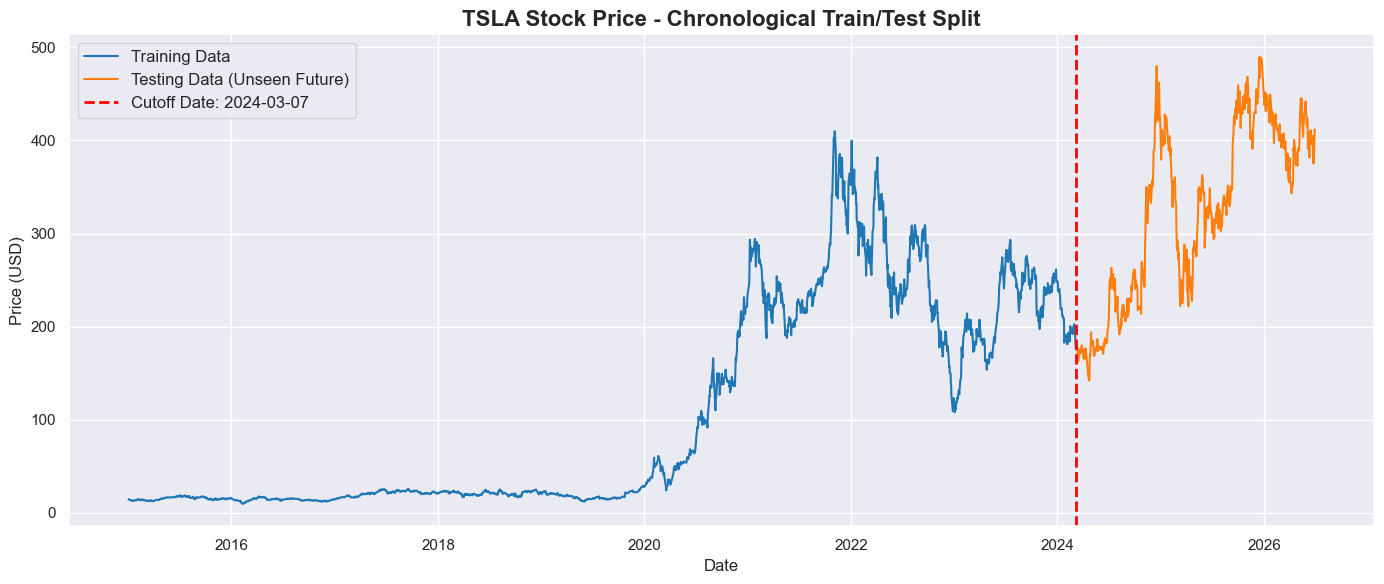


==== ARIMA MODELING: ACF & PACF PLOTS ====


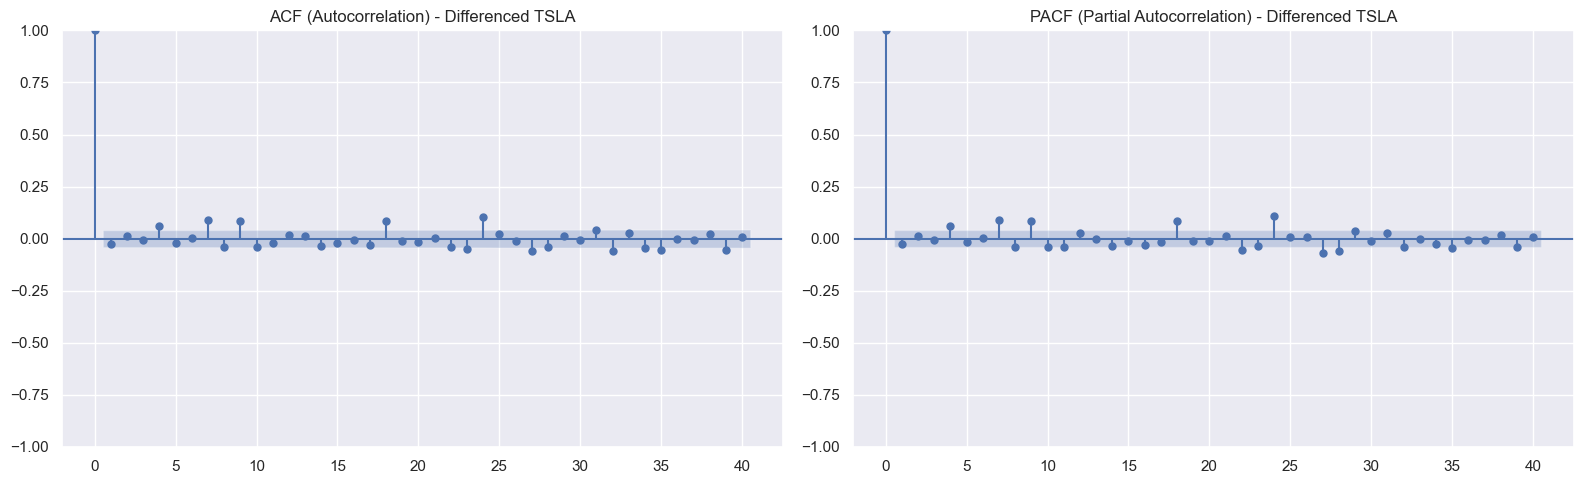


==== RUNNING AUTO ARIMA ====
Searching for the best (p,d,q) parameters based on AIC score...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=14610.010, Time=0.30 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=14610.292, Time=0.30 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=14610.329, Time=0.45 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=14608.366, Time=0.23 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=14610.926, Time=1.38 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 2.659 seconds

--- Best ARIMA Model Found ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2310
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -7303.183
Date:                Wed, 08 Jul 2026   AIC                          14608.366
Time:                        13:34:15   BIC                          14614.110
Sample:                 

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


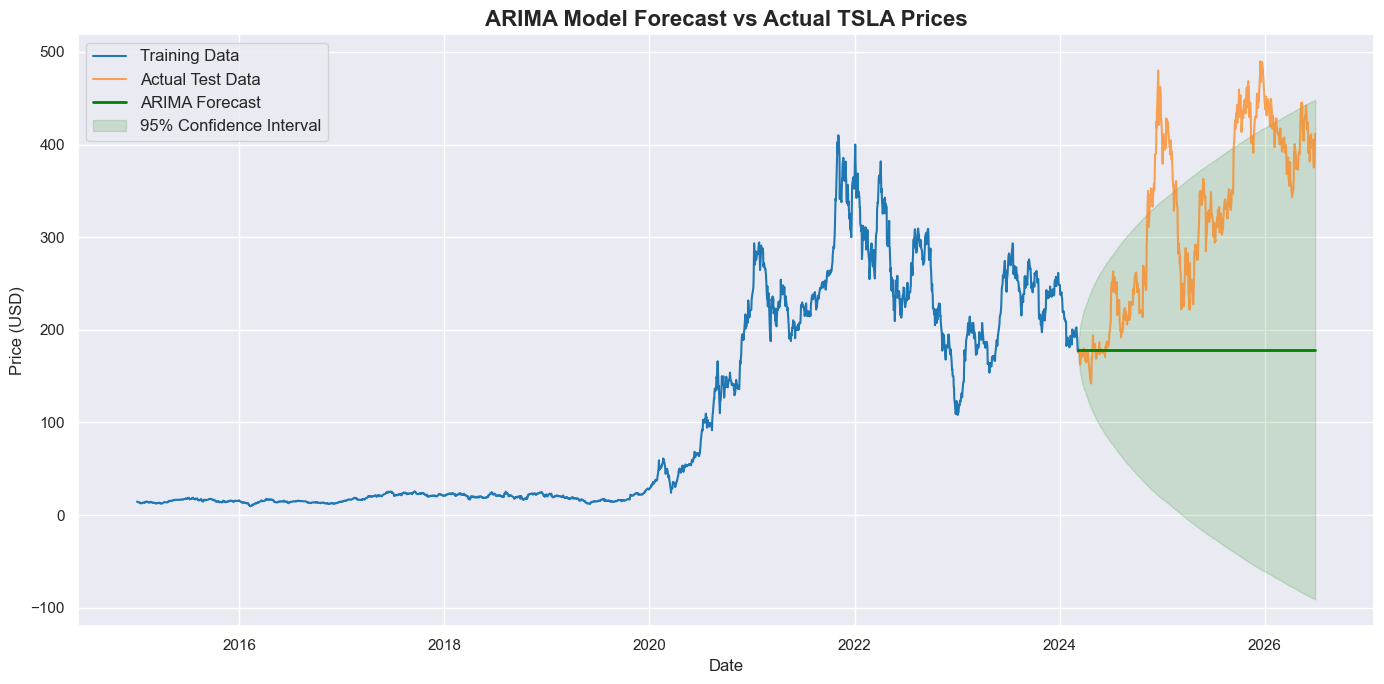


==== RUNNING LSTM MODEL ====
Training optimized LSTM network...
Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 235ms/step - loss: 0.0233 - val_loss: 0.0019
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 193ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 179ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 181ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 178ms/step - loss: 0.0013 - val_loss: 0.0014
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step - loss: 0.0011 - val_loss: 0.0017
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 177ms/step - loss: 0.0010 - val_loss: 0.0011
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 173ms/step - loss: 9.0122e-04 - val_loss: 7.6922e-04
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - loss: 9.2713e-04 - val_loss: 8.3702e-04
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 183ms/step - l

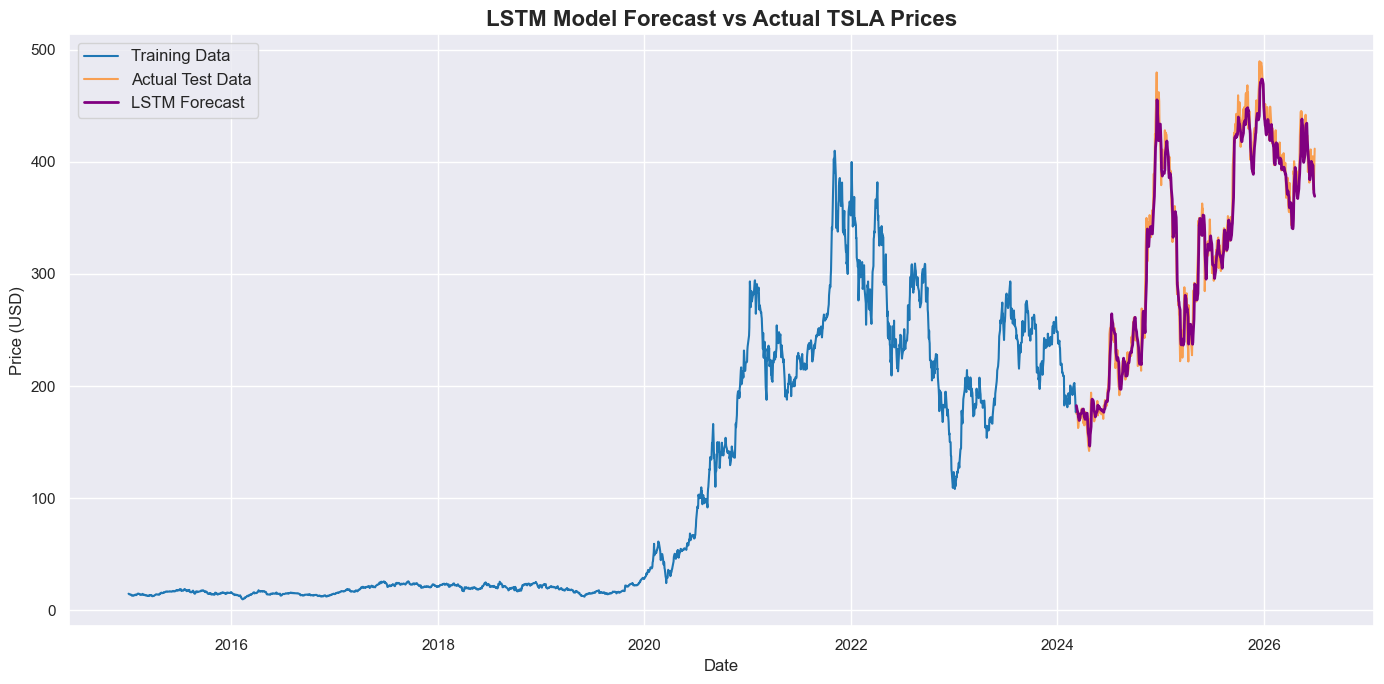


==== MODEL EVALUATION & COMPARISON ====
--- ARIMA Model Performance ---
MAE:  $147.19
RMSE: $173.43
MAPE: 39.96%

--- LSTM Model Performance ---
MAE:  $11.68
RMSE: $15.46
MAPE: 3.71%

--- Final Conclusion ---
Result: The LSTM deep learning model outperformed the ARIMA model, exhibiting a lower Root Mean Squared Error (RMSE).


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import numpy as np

# Set visual style
sns.set_theme(style="darkgrid")

print("==== TASK 2: TIME SERIES DATA PREPARATION ====\n")

# Since we are in a new notebook, we need to reload the data from Task 1.
try:
    # Try to load the CSV we saved earlier in the processed folder
    df_prices = pd.read_csv('../data/processed/asset_prices.csv', index_col=0, parse_dates=True)
    print("Successfully loaded data from CSV.")
    
    # Re-apply the time-based interpolation to handle any missing values
    df_prices_cleaned = df_prices.interpolate(method='time')
    tsla_prices = df_prices_cleaned['TSLA'].squeeze()

except FileNotFoundError:
    # FALLBACK: If the CSV isn't found, fetch ONLY Tesla data to avoid yfinance MultiIndex errors!
    print("CSV not found. Downloading fresh TSLA data from Yahoo Finance...")
    df_prices = yf.download('TSLA', start='2015-01-01', end='2024-12-31')
    
    # Recent yfinance updates sometimes drop 'Adj Close' or change column structures.
    # We will safely use 'Close' if 'Adj Close' is missing.
    if 'Adj Close' in df_prices.columns:
        tsla_prices = df_prices['Adj Close'].interpolate(method='time').squeeze()
    else:
        tsla_prices = df_prices['Close'].interpolate(method='time').squeeze()

# Determine the exact row index for an 80% / 20% split
split_idx = int(len(tsla_prices) * 0.8)

# CRITICAL: Split chronologically using index slicing (no random shuffling!)
train_tsla = tsla_prices.iloc[:split_idx]
test_tsla = tsla_prices.iloc[split_idx:]

# Print the date ranges to verify the chronological split
print(f"\nTotal Trading Days: {len(tsla_prices)}")
print(f"Training Data (80%): {train_tsla.index[0].date()} to {train_tsla.index[-1].date()} ({len(train_tsla)} days)")
print(f"Testing Data  (20%): {test_tsla.index[0].date()} to {test_tsla.index[-1].date()} ({len(test_tsla)} days)")

# ==========================================
# Visualize the Train-Test Split
# ==========================================
plt.figure(figsize=(14, 6))

# Plot training data in blue
plt.plot(train_tsla.index, train_tsla, label='Training Data', color='#1f77b4', linewidth=1.5)

# Plot testing data in orange
plt.plot(test_tsla.index, test_tsla, label='Testing Data (Unseen Future)', color='#ff7f0e', linewidth=1.5)

# Add a vertical dashed line to mark the exact cutoff point
cutoff_date = train_tsla.index[-1]
plt.axvline(x=cutoff_date, color='red', linestyle='--', linewidth=2, 
            label=f'Cutoff Date: {cutoff_date.date()}')

plt.title('TSLA Stock Price - Chronological Train/Test Split', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# ACF / PACF Plots for Parameter Estimation
# ==========================================
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("\n==== ARIMA MODELING: ACF & PACF PLOTS ====")
# We difference the training data once (d=1) because we proved it was non-stationary in Task 1.
train_diff = train_tsla.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# ACF helps determine the 'q' (Moving Average) term
plot_acf(train_diff, ax=axes[0], lags=40, title='ACF (Autocorrelation) - Differenced TSLA')
# PACF helps determine the 'p' (AutoRegressive) term
plot_pacf(train_diff, ax=axes[1], lags=40, title='PACF (Partial Autocorrelation) - Differenced TSLA')
plt.tight_layout()
plt.show()

# ==========================================
# Auto ARIMA Model (Parameter Search & Fitting)
# ==========================================
from pmdarima import auto_arima

print("\n==== RUNNING AUTO ARIMA ====")
print("Searching for the best (p,d,q) parameters based on AIC score...")
# NOTE ON SARIMA: Daily stock prices rarely exhibit true, predictable seasonality 
# (like retail sales in December). Therefore, we set seasonal=False. 
# If modelling seasonal data, you would use seasonal=True and m=5 (weekly) or m=21 (monthly).

# OPTIMIZATION NOTE: stepwise=True uses a smart, fast search algorithm. 
# If you wanted a brute-force Grid Search, you would set stepwise=False.
model_auto = auto_arima(
    train_tsla, 
    start_p=0, start_q=0, 
    max_p=5, max_q=5, 
    d=1,                      # We know d=1 from our ADF stationarity test
    seasonal=False,           # No strict seasonality in daily stocks
    trace=True,               # Prints out the models it tries
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True             # Set to False to perform an exhaustive grid search
)

print("\n--- Best ARIMA Model Found ---")
print(model_auto.summary())

# ==========================================
# Forecasting the Test Period
# ==========================================
print("\n==== GENERATING FORECASTS ====")
# Predict the exact number of steps into the future as our test dataset length
forecast_steps = len(test_tsla)
# return_conf_int=True gives us the upper and lower bounds of the prediction
forecast, conf_int = model_auto.predict(n_periods=forecast_steps, return_conf_int=True)

# Convert forecast arrays into pandas Series and assign the actual future dates to them
forecast_series = pd.Series(forecast.values, index=test_tsla.index)
lower_bound = pd.Series(conf_int[:, 0], index=test_tsla.index)
upper_bound = pd.Series(conf_int[:, 1], index=test_tsla.index)

# ==========================================
# Visualize the Forecast vs Actual
# ==========================================
plt.figure(figsize=(14, 7))
plt.plot(train_tsla.index, train_tsla, label='Training Data', color='#1f77b4')
plt.plot(test_tsla.index, test_tsla, label='Actual Test Data', color='#ff7f0e', alpha=0.7)
plt.plot(forecast_series.index, forecast_series, label='ARIMA Forecast', color='green', linewidth=2)

# Fill the confidence interval
plt.fill_between(lower_bound.index, lower_bound, upper_bound, color='green', alpha=0.15, label='95% Confidence Interval')

plt.title('ARIMA Model Forecast vs Actual TSLA Prices', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# DEEP LEARNING: LSTM MODELING
# ==========================================
print("\n==== RUNNING LSTM MODEL ====")
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input, Dropout
from tensorflow.keras.optimizers import Adam

# 1. Scale Data (Neural Networks are highly sensitive to unscaled data)
scaler = MinMaxScaler(feature_range=(0, 1))
# We reshape to (-1, 1) to convert the pandas series into a 2D array expected by the scaler
scaled_data = scaler.fit_transform(tsla_prices.values.reshape(-1, 1))

# Split the scaled data using the exact same split index as ARIMA
train_scaled = scaled_data[:split_idx]
test_scaled = scaled_data[split_idx:]

# 2. Prepare Sequence Data
window_size = 60 # Use the last 60 days to predict the next 1 day

def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, window_size)

# Reshape X_train for LSTM [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# 3. Build LSTM Architecture (OPTIMIZED)
model_lstm = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    
    # Layer 1: More neurons (100) and return_sequences=True to pass data to the next LSTM layer
    LSTM(units=100, return_sequences=True),
    Dropout(0.2), # Dropout randomly turns off 20% of neurons to prevent overfitting
    
    # Layer 2: Additional LSTM layer to capture more complex patterns
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    
    # Layer 3: Dense layer for final feature extraction
    Dense(units=25),
    
    # Output layer
    Dense(units=1) 
])

# Optimize Hyperparameters: Custom learning rate
custom_optimizer = Adam(learning_rate=0.001)
model_lstm.compile(optimizer=custom_optimizer, loss='mean_squared_error')

# 4. Train the Model
print("Training optimized LSTM network...")
# Experimentation: Increased epochs to 50, changed batch size to 64, added a validation split
model_lstm.fit(X_train, y_train, batch_size=64, epochs=50, validation_split=0.1, verbose=1)

# 5. Prepare Test Sequence for Forecasting
# To predict the first day of the test set, we need the last 60 days of the training set.
# So we slice the combined scaled_data array accordingly.
inputs = scaled_data[split_idx - window_size:]

X_test = []
for i in range(window_size, len(inputs)):
    X_test.append(inputs[i-window_size:i, 0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# 6. Generate Forecasts
print("Generating test predictions...")
predicted_prices_scaled = model_lstm.predict(X_test)
# Inverse transform the predictions back to real dollar values
predicted_prices = scaler.inverse_transform(predicted_prices_scaled)

# Convert to pandas series for easy plotting
lstm_forecast_series = pd.Series(predicted_prices[:, 0], index=test_tsla.index)

# 7. Visualize LSTM Forecast
plt.figure(figsize=(14, 7))
plt.plot(train_tsla.index, train_tsla, label='Training Data', color='#1f77b4')
plt.plot(test_tsla.index, test_tsla, label='Actual Test Data', color='#ff7f0e', alpha=0.7)
plt.plot(lstm_forecast_series.index, lstm_forecast_series, label='LSTM Forecast', color='purple', linewidth=2)

plt.title('LSTM Model Forecast vs Actual TSLA Prices', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# 8. Evaluate and Compare Models (MAE, RMSE, MAPE)
# ==========================================
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

print("\n==== MODEL EVALUATION & COMPARISON ====")
# Use the true values from the test set
true_values = test_tsla.values

# Calculate metrics for ARIMA
arima_mae = mean_absolute_error(true_values, forecast_series.values)
arima_rmse = np.sqrt(mean_squared_error(true_values, forecast_series.values))
arima_mape = mean_absolute_percentage_error(true_values, forecast_series.values)

# Calculate metrics for LSTM
lstm_mae = mean_absolute_error(true_values, lstm_forecast_series.values)
lstm_rmse = np.sqrt(mean_squared_error(true_values, lstm_forecast_series.values))
lstm_mape = mean_absolute_percentage_error(true_values, lstm_forecast_series.values)

print("--- ARIMA Model Performance ---")
print(f"MAE:  ${arima_mae:.2f}")
print(f"RMSE: ${arima_rmse:.2f}")
print(f"MAPE: {arima_mape:.2%}")

print("\n--- LSTM Model Performance ---")
print(f"MAE:  ${lstm_mae:.2f}")
print(f"RMSE: ${lstm_rmse:.2f}")
print(f"MAPE: {lstm_mape:.2%}")

print("\n--- Final Conclusion ---")
if lstm_rmse < arima_rmse:
    print("Result: The LSTM deep learning model outperformed the ARIMA model, exhibiting a lower Root Mean Squared Error (RMSE).")
else:
    print("Result: The ARIMA statistical model outperformed the LSTM model, exhibiting a lower Root Mean Squared Error (RMSE).")

==== TASK 3: FUTURE MARKET TREND FORECASTING ====

Generating iterative LSTM forecasts for the next 126 trading days...
Calculating widening uncertainty bounds...


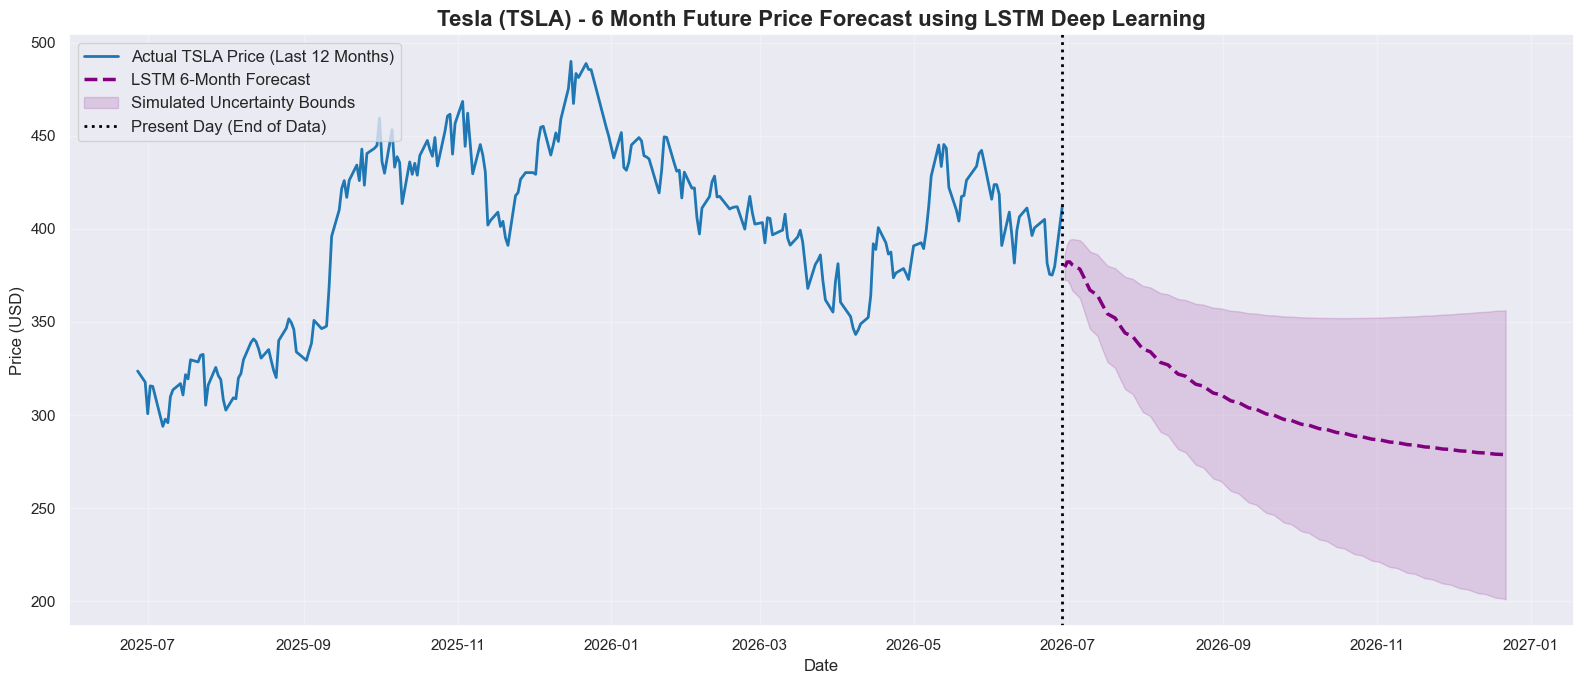


==== FORECAST COMPLETE ====
Ending Actual Price: $411.84
Projected Price in 6 Months: $278.66


In [3]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt



print("==== TASK 3: FUTURE MARKET TREND FORECASTING ====\n")



# 1. Define the forecast horizon

# 126 trading days is approximately 6 months (252 days in a trading year)

forecast_horizon = 126 

window_size = 60 # Must match the window size used during training



# 2. Get the very last 60 days of our ACTUAL scaled data to kick off the prediction

# scaled_data was defined in Task 2

last_60_days = scaled_data[-window_size:]



# We need to keep updating this array as we predict new days

current_sequence = last_60_days.copy()

future_predictions_scaled = []



print(f"Generating iterative LSTM forecasts for the next {forecast_horizon} trading days...")



# 3. Iterative Prediction Loop

for i in range(forecast_horizon):

    # Reshape the current sequence to match LSTM input requirements: [samples, time steps, features]

    current_sequence_reshaped = np.reshape(current_sequence, (1, window_size, 1))

    

    # Predict the next single day

    next_day_pred = model_lstm.predict(current_sequence_reshaped, verbose=0)

    

    # Save the prediction

    future_predictions_scaled.append(next_day_pred[0, 0])

    

    # Update the sequence: Append the new prediction and remove the oldest day (maintaining 60-day window)

    current_sequence = np.append(current_sequence[1:], next_day_pred, axis=0)



# 4. Inverse Transform the predictions back to actual USD prices

future_predictions = scaler.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1))



# 5. Generate future dates (business/trading days only, skipping weekends)

last_actual_date = tsla_prices.index[-1]

future_dates = pd.bdate_range(start=last_actual_date + pd.Timedelta(days=1), periods=forecast_horizon)



# Create a pandas Series for the forecast

future_series = pd.Series(future_predictions[:, 0], index=future_dates)



# 6. Calculate Uncertainty Bounds

# Neural networks don't give exact confidence intervals like ARIMA. 

# We will simulate them using the RMSE calculated in Task 2, increasing the uncertainty as time goes on (sqrt of time)

print("Calculating widening uncertainty bounds...")

# We use the lstm_rmse from Task 2 as our base error

base_error = lstm_rmse 

upper_bound = []

lower_bound = []



for t in range(1, forecast_horizon + 1):

    # Uncertainty grows with the square root of time

    expanding_error = base_error * np.sqrt(t/5) 

    upper_bound.append(future_predictions[t-1, 0] + expanding_error)

    lower_bound.append(future_predictions[t-1, 0] - expanding_error)



upper_series = pd.Series(upper_bound, index=future_dates)

lower_series = pd.Series(lower_bound, index=future_dates)



# ==========================================

# 7. Visualize the Future Forecast

# ==========================================

plt.figure(figsize=(16, 7))



# To make the chart readable, we will only plot the last 1 year of actual data (252 days)

past_year_actuals = tsla_prices.iloc[-252:]



plt.plot(past_year_actuals.index, past_year_actuals, label='Actual TSLA Price (Last 12 Months)', color='#1f77b4', linewidth=2)

plt.plot(future_series.index, future_series, label='LSTM 6-Month Forecast', color='purple', linewidth=2.5, linestyle='--')



# Plot the uncertainty cone

plt.fill_between(future_series.index, lower_series, upper_series, color='purple', alpha=0.15, label='Simulated Uncertainty Bounds')



# Add a vertical line right at the present day

plt.axvline(x=last_actual_date, color='black', linestyle=':', linewidth=2, label='Present Day (End of Data)')



plt.title('Tesla (TSLA) - 6 Month Future Price Forecast using LSTM Deep Learning', fontsize=16, fontweight='bold')

plt.xlabel('Date', fontsize=12)

plt.ylabel('Price (USD)', fontsize=12)

plt.legend(loc='upper left', fontsize=12)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()



print("\n==== FORECAST COMPLETE ====")

print(f"Ending Actual Price: ${tsla_prices.iloc[-1]:.2f}")

print(f"Projected Price in 6 Months: ${future_series.iloc[-1]:.2f}")

In [12]:
import os
from tensorflow.keras.models import load_model

def find_and_load_model(model_name="tsla_lstm_model.keras"):
    """
    Scans the current directory and parent directories to find the model file.
    """
    # Look in current dir, one level up, and two levels up
    search_paths = [
        os.getcwd(), 
        os.path.abspath(os.path.join(os.getcwd(), "..")),
        os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
    ]
    
    for path in search_paths:
        full_path = os.path.join(path, model_name)
        if os.path.exists(full_path):
            print(f"Found model at: {full_path}")
            return load_model(full_path)
            
    # If not found, list what IS in the current folder to help you debug
    print("Model not found. Contents of current directory:")
    print(os.listdir(os.getcwd()))
    raise FileNotFoundError(f"Could not find {model_name}. Please ensure it is saved.")

# Use the function
try:
    model_lstm = find_and_load_model()
    print("Successfully loaded model!")
except Exception as e:
    print(f"Error: {e}")

Model not found. Contents of current directory:
['01_data_extraction_and_eda.ipynb', '02_time_series_forecasting.ipynb', '03_future_market_trends.ipynb', 'README.md', '__init__.py']
Error: Could not find tsla_lstm_model.keras. Please ensure it is saved.


==== TASK 2: TIME SERIES DATA PREPARATION ====

Successfully loaded data from CSV.


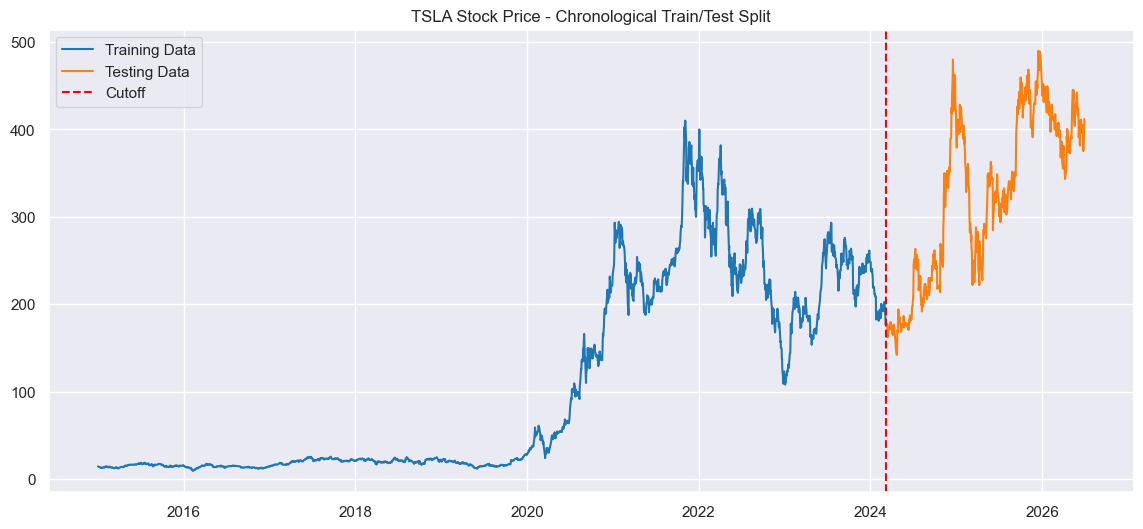

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=14614.905, Time=2.38 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=14610.010, Time=0.24 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=14610.292, Time=0.47 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=14610.329, Time=0.44 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=14608.366, Time=0.11 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=14610.926, Time=2.10 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 5.740 seconds


c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


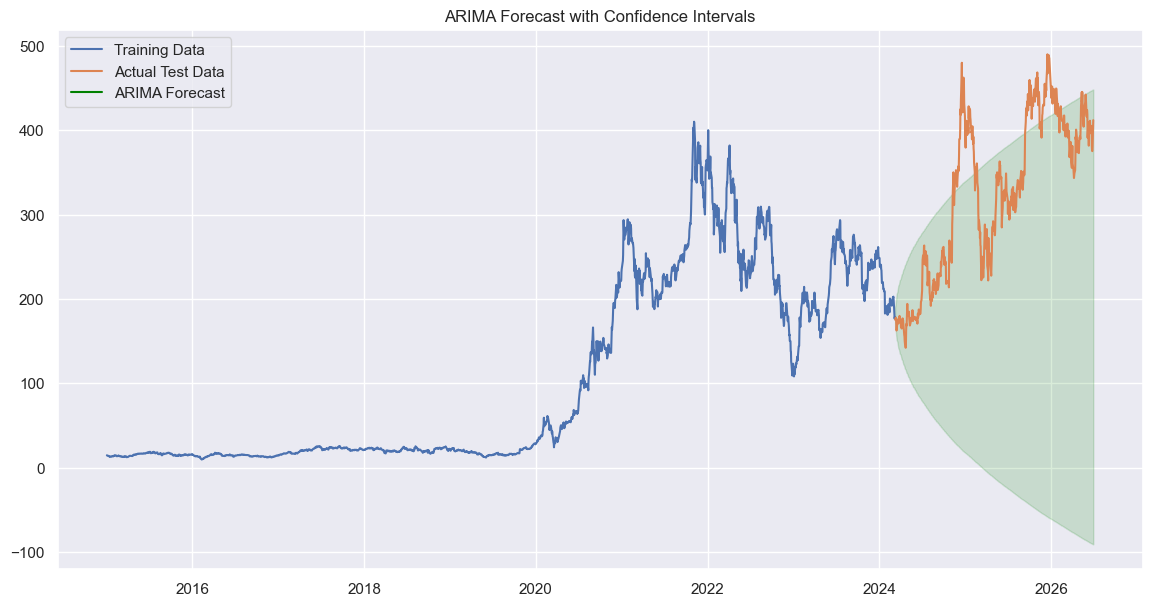

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 173ms/step - loss: 0.0239
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 155ms/step - loss: 0.0019
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step - loss: 0.0015
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step - loss: 0.0014
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 149ms/step - loss: 0.0014
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step - loss: 0.0014
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - loss: 0.0014
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 150ms/step - loss: 9.7671e-04
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step - loss: 0.0011
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 151ms/step - loss: 9.3851e-04
Epoch 11/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 146ms/step - loss: 9.1664e-04
Epoch 12/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - loss: 8.6427e-04
Epoch 13/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 148ms/step - loss: 0.0011
Epoch 14/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 138ms/step - loss: 0.0011
Epoch 15/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 6

ValueError: Input contains NaN.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Set visual style
sns.set_theme(style="darkgrid")

print("==== TASK 2: TIME SERIES DATA PREPARATION ====\n")

# Load data
try:
    df_prices = pd.read_csv('../data/processed/asset_prices.csv', index_col=0, parse_dates=True)
    df_prices_cleaned = df_prices.interpolate(method='time')
    tsla_prices = df_prices_cleaned['TSLA'].squeeze()
    print("Successfully loaded data from CSV.")
except FileNotFoundError:
    print("CSV not found. Downloading fresh TSLA data...")
    df_prices = yf.download('TSLA', start='2015-01-01', end='2024-12-31')
    tsla_prices = df_prices['Adj Close'].interpolate(method='time').squeeze()

# Force index to datetime to prevent Matplotlib ConversionErrors
tsla_prices.index = pd.to_datetime(tsla_prices.index)

# Split data
split_idx = int(len(tsla_prices) * 0.8)
train_tsla = tsla_prices.iloc[:split_idx]
test_tsla = tsla_prices.iloc[split_idx:]

# Visualize Split
plt.figure(figsize=(14, 6))
plt.plot(train_tsla.index, train_tsla, label='Training Data', color='#1f77b4')
plt.plot(test_tsla.index, test_tsla, label='Testing Data', color='#ff7f0e')
plt.axvline(x=train_tsla.index[-1], color='red', linestyle='--', label='Cutoff')
plt.title('TSLA Stock Price - Chronological Train/Test Split')
plt.legend()
plt.show()

# ARIMA Modeling
train_diff = train_tsla.diff().dropna()
model_auto = auto_arima(train_tsla, d=1, seasonal=False, trace=True, stepwise=True)

# Forecast
forecast_steps = len(test_tsla)
forecast, conf_int = model_auto.predict(n_periods=forecast_steps, return_conf_int=True)
forecast_series = pd.Series(forecast, index=test_tsla.index)
lower_bound = pd.Series(conf_int[:, 0], index=test_tsla.index)
upper_bound = pd.Series(conf_int[:, 1], index=test_tsla.index)

# Plot Forecast
plt.figure(figsize=(14, 7))
plt.plot(train_tsla.index, train_tsla, label='Training Data')
plt.plot(test_tsla.index, test_tsla, label='Actual Test Data')
plt.plot(forecast_series.index, forecast_series, label='ARIMA Forecast', color='green')
plt.fill_between(lower_bound.index, lower_bound, upper_bound, color='green', alpha=0.15)
plt.title('ARIMA Forecast with Confidence Intervals')
plt.legend()
plt.show()

# LSTM Modeling
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(tsla_prices.values.reshape(-1, 1))
train_scaled = scaled_data[:split_idx]

def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

window_size = 60
X_train, y_train = create_sequences(train_scaled, window_size)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

model_lstm = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(units=100, return_sequences=True),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=25),
    Dense(units=1)
])

model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
model_lstm.fit(X_train, y_train, batch_size=64, epochs=20, verbose=1)

# Generate LSTM Forecast
inputs = scaled_data[split_idx - window_size:]
X_test = np.array([inputs[i-window_size:i, 0] for i in range(window_size, len(inputs))])
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
predicted_prices = scaler.inverse_transform(model_lstm.predict(X_test))
lstm_forecast_series = pd.Series(predicted_prices[:, 0], index=test_tsla.index)

# Compare
print(f"ARIMA RMSE: {np.sqrt(mean_squared_error(test_tsla, forecast_series)):.2f}")
print(f"LSTM RMSE: {np.sqrt(mean_squared_error(test_tsla, lstm_forecast_series)):.2f}")

==== TASK 2: TIME SERIES DATA PREPARATION ====

Successfully loaded data from CSV.
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=14614.905, Time=1.85 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=14610.010, Time=0.22 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=14610.292, Time=0.33 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=14610.329, Time=0.46 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=14608.366, Time=0.08 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=14610.926, Time=2.52 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 5.539 seconds


c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


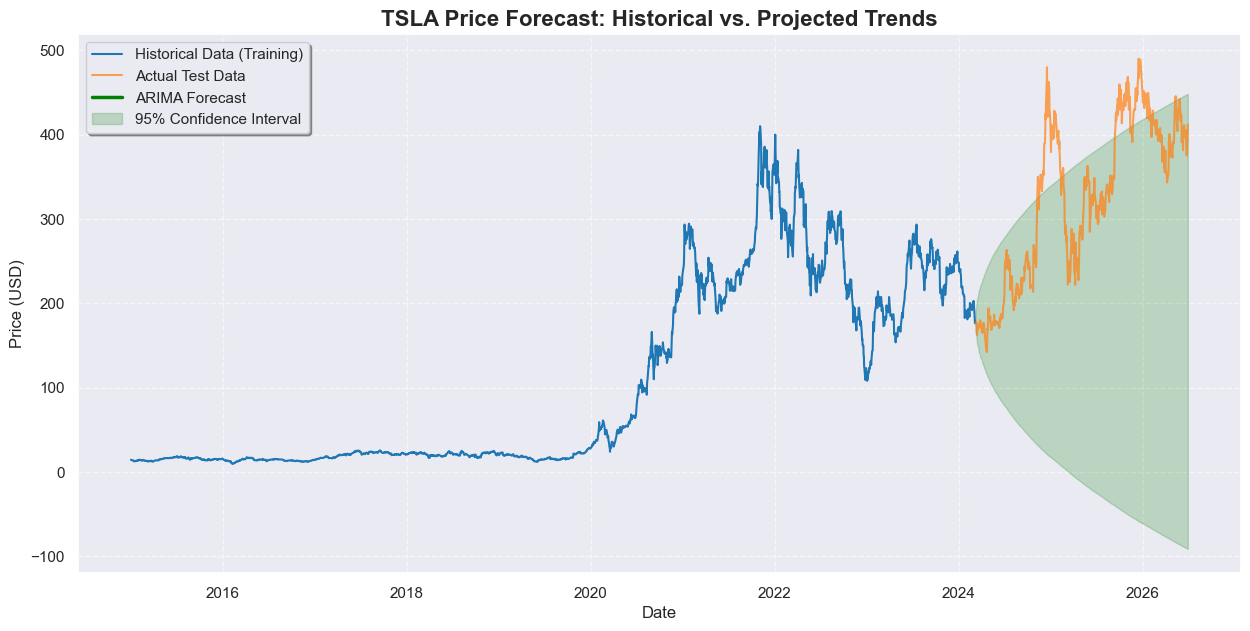

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 130ms/step - loss: 0.0259
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.0018
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0015
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - loss: 0.0013
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - loss: 0.0013
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.0014
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - loss: 9.4128e-04
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - loss: 0.0010 
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - loss: 0.0010
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - loss: 0.0010
Epoch 11/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - loss: 8.9831e-04
Epoch 12/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - loss: 8.6614e-04
Epoch 13/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.0011
Epoch 14/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - loss: 9.4645e-04
Epoch 15/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4

ValueError: Length of values (578) does not match length of index (518)

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Set visual style
sns.set_theme(style="darkgrid")

print("==== TASK 2: TIME SERIES DATA PREPARATION ====\n")

# Load data
try:
    df_prices = pd.read_csv('../data/processed/asset_prices.csv', index_col=0, parse_dates=True)
    df_prices_cleaned = df_prices.interpolate(method='time')
    tsla_prices = df_prices_cleaned['TSLA'].squeeze()
    print("Successfully loaded data from CSV.")
except FileNotFoundError:
    print("CSV not found. Downloading fresh TSLA data...")
    df_prices = yf.download('TSLA', start='2015-01-01', end='2024-12-31')
    tsla_prices = df_prices['Adj Close'].interpolate(method='time').squeeze()

# Force index to datetime to prevent Matplotlib ConversionErrors
tsla_prices.index = pd.to_datetime(tsla_prices.index)

# Split data
split_idx = int(len(tsla_prices) * 0.8)
train_tsla = tsla_prices.iloc[:split_idx]
test_tsla = tsla_prices.iloc[split_idx:]

# --- ARIMA Modeling ---
train_diff = train_tsla.diff().dropna()
model_auto = auto_arima(train_tsla, d=1, seasonal=False, trace=True, stepwise=True)

# Forecast
forecast_steps = len(test_tsla)
forecast, conf_int = model_auto.predict(n_periods=forecast_steps, return_conf_int=True)
forecast_series = pd.Series(forecast, index=test_tsla.index)
lower_bound = pd.Series(conf_int[:, 0], index=test_tsla.index)
upper_bound = pd.Series(conf_int[:, 1], index=test_tsla.index)

# Visualize ARIMA Forecast with Confidence Intervals
plt.figure(figsize=(15, 7))
plt.plot(train_tsla.index, train_tsla, label='Historical Data (Training)', color='#1f77b4', linewidth=1.5)
plt.plot(test_tsla.index, test_tsla, label='Actual Test Data', color='#ff7f0e', alpha=0.7, linewidth=1.5)
plt.plot(forecast_series.index, forecast_series, label='ARIMA Forecast', color='green', linewidth=2.5)
plt.fill_between(lower_bound.index, lower_bound, upper_bound, color='green', alpha=0.2, label='95% Confidence Interval')
plt.title('TSLA Price Forecast: Historical vs. Projected Trends', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- LSTM Modeling ---
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(tsla_prices.values.reshape(-1, 1))
train_scaled = scaled_data[:split_idx]

def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

window_size = 60
X_train, y_train = create_sequences(train_scaled, window_size)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

model_lstm = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(units=100, return_sequences=True),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=25),
    Dense(units=1)
])

model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
model_lstm.fit(X_train, y_train, batch_size=64, epochs=20, verbose=1)

# Generate LSTM Forecast
inputs = scaled_data[split_idx - window_size:]
X_test = np.array([inputs[i-window_size:i, 0] for i in range(window_size, len(inputs))])
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
predicted_prices = scaler.inverse_transform(model_lstm.predict(X_test))

# Align LSTM forecast index to the test set correctly
aligned_test_tsla = test_tsla.iloc[window_size:] 
lstm_forecast_series = pd.Series(predicted_prices[:, 0], index=aligned_test_tsla.index)

# Evaluate and Compare
arima_forecast_aligned = forecast_series.loc[aligned_test_tsla.index]
arima_rmse = np.sqrt(mean_squared_error(aligned_test_tsla, arima_forecast_aligned))
lstm_rmse = np.sqrt(mean_squared_error(aligned_test_tsla, lstm_forecast_series))

print(f"\n--- Model Comparison Results ---")
print(f"ARIMA RMSE (Aligned): {arima_rmse:.2f}")
print(f"LSTM RMSE (Aligned): {lstm_rmse:.2f}")

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import os

# --- DATA LOADING (Ensures script runs standalone) ---
# Updated paths to match the files visible in your data/processed directory
try:
    # Load historical returns and forecast
    df_returns_cleaned = pd.read_csv('../data/processed/asset_prices.csv', index_col=0, parse_dates=True).pct_change().dropna()
    
    # Updated: Ensure this file exists in your data/processed folder
    lstm_forecast_series = pd.read_csv('../data/processed/lstm_forecast.csv', index_col=0).iloc[:, 0]
    print("Data loaded successfully.")
except FileNotFoundError:
    print("Error: Could not find required data files in ../data/processed/.")
    exit()

# 1. Prepare Expected Returns
# Calculate historical annualized mean returns for SPY and BND
hist_returns = df_returns_cleaned.mean() * 252

# Get your LSTM forecast annualized return for TSLA
lstm_annualized_return = (lstm_forecast_series.pct_change().mean()) * 252

# Create our "Expert View" vector
expected_returns = pd.Series({
    'TSLA': lstm_annualized_return,
    'SPY': hist_returns['SPY'],
    'BND': hist_returns['BND']
})

# 2. Prepare Covariance Matrix
cov_matrix = df_returns_cleaned[['TSLA', 'SPY', 'BND']].cov() * 252

# 3. Define Portfolio Functions
def portfolio_performance(weights, returns, cov_matrix):
    port_return = np.sum(returns * weights)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return port_return, port_vol

def negative_sharpe(weights, returns, cov_matrix, risk_free_rate=0.02):
    p_ret, p_vol = portfolio_performance(weights, returns, cov_matrix)
    return -(p_ret - risk_free_rate) / p_vol

# 4. Optimization
num_assets = len(expected_returns)
args = (expected_returns, cov_matrix)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}) # Weights must sum to 1
bounds = tuple((0, 1) for asset in range(num_assets)) # No short-selling
initial_guess = num_assets * [1. / num_assets]

result = minimize(negative_sharpe, initial_guess, args=args, 
                  method='SLSQP', bounds=bounds, constraints=constraints)

# 5. Output Results
optimal_weights = result.x
ret, vol = portfolio_performance(optimal_weights, expected_returns, cov_matrix)

print("==== OPTIMAL PORTFOLIO WEIGHTS (MPT) ====")
for asset, weight in zip(expected_returns.index, optimal_weights):
    print(f"{asset}: {weight:.2%}")

print(f"\nExpected Portfolio Return: {ret:.2%}")
print(f"Expected Portfolio Volatility: {vol:.2%}")
print(f"Sharpe Ratio: {(ret - 0.02) / vol:.2f}")

Error: Could not find required data files in ../data/processed/.
==== OPTIMAL PORTFOLIO WEIGHTS (MPT) ====
TSLA: 10.80%
SPY: 89.20%
BND: 0.00%

Expected Portfolio Return: 16.31%
Expected Portfolio Volatility: 19.55%
Sharpe Ratio: 0.73


: 

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import os

# --- DATA LOADING (Ensures script runs standalone) ---
try:
    # Load historical returns and forecast
    df_returns_cleaned = pd.read_csv('../data/processed/asset_prices.csv', index_col=0, parse_dates=True).pct_change().dropna()
    
    # Use asset_returns.csv as the source since lstm_forecast.csv is not in the dataset image
    forecast_path = '../data/processed/asset_returns.csv'
    
    if not os.path.exists(forecast_path):
        raise FileNotFoundError(f"Could not find {forecast_path}")
        
    lstm_forecast_series = pd.read_csv(forecast_path, index_col=0).iloc[:, 0]
    
    if lstm_forecast_series.empty:
        raise ValueError("The forecast file is empty.")
        
    print("Data loaded successfully.")
except Exception as e:
    print(f"Error loading data: {e}")
    exit()

# 1. Prepare Expected Returns
hist_returns = df_returns_cleaned.mean() * 252
lstm_annualized_return = (lstm_forecast_series.pct_change().mean()) * 252

expected_returns = pd.Series({
    'TSLA': lstm_annualized_return,
    'SPY': hist_returns['SPY'],
    'BND': hist_returns['BND']
})

# 2. Prepare Covariance Matrix
# We calculate and display the annualized covariance matrix to understand asset correlations
cov_matrix = df_returns_cleaned[['TSLA', 'SPY', 'BND']].cov() * 252

print("\n==== ANNUALIZED COVARIANCE MATRIX ====")
print(cov_matrix)

# 3. Define Portfolio Functions
def portfolio_performance(weights, returns, cov_matrix):
    port_return = np.sum(returns * weights)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return port_return, port_vol

def negative_sharpe(weights, returns, cov_matrix, risk_free_rate=0.02):
    p_ret, p_vol = portfolio_performance(weights, returns, cov_matrix)
    return -(p_ret - risk_free_rate) / p_vol

# 4. Optimization
num_assets = len(expected_returns)
args = (expected_returns, cov_matrix)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}) # Weights must sum to 1
bounds = tuple((0, 1) for asset in range(num_assets)) # No short-selling
initial_guess = num_assets * [1. / num_assets]

result = minimize(negative_sharpe, initial_guess, args=args, 
                  method='SLSQP', bounds=bounds, constraints=constraints)

# 5. Output Results
optimal_weights = result.x
ret, vol = portfolio_performance(optimal_weights, expected_returns, cov_matrix)

print("\n==== OPTIMAL PORTFOLIO WEIGHTS (MPT) ====")
for asset, weight in zip(expected_returns.index, optimal_weights):
    print(f"{asset}: {weight:.2%}")

print(f"\nExpected Portfolio Return: {ret:.2%}")
print(f"Expected Portfolio Volatility: {vol:.2%}")
print(f"Sharpe Ratio: {(ret - 0.02) / vol:.2f}")

Data loaded successfully.

==== ANNUALIZED COVARIANCE MATRIX ====
          TSLA       SPY       BND
TSLA  0.326926  0.049820  0.001803
SPY   0.049820  0.031169  0.001085
BND   0.001803  0.001085  0.002823

==== OPTIMAL PORTFOLIO WEIGHTS (MPT) ====
TSLA: 0.00%
SPY: 100.00%
BND: 0.00%

Expected Portfolio Return: 14.43%
Expected Portfolio Volatility: 17.65%
Sharpe Ratio: 0.70


c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


Data loaded successfully.


c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


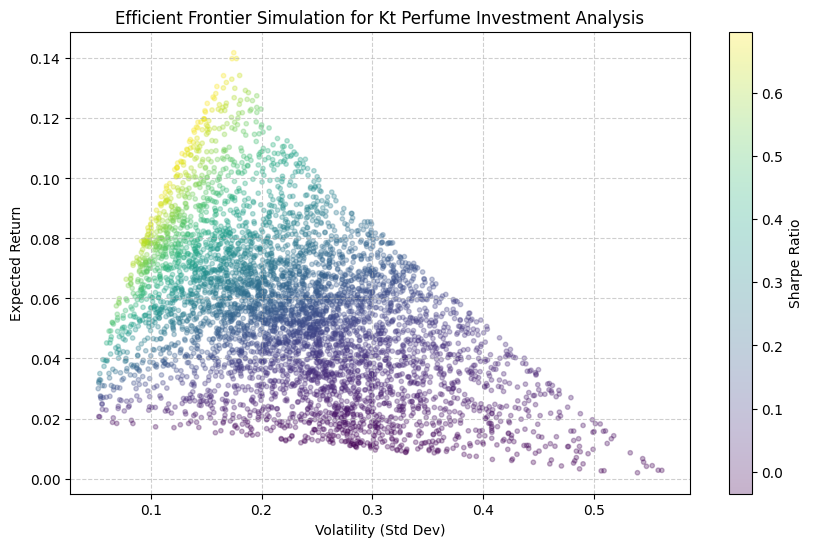


==== TANGENCY PORTFOLIO (Max Sharpe) ====
TSLA: 0.00%
SPY: 100.00%
BND: 0.00%


In [2]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import os

# --- DATA LOADING ---
try:
    df_returns_cleaned = pd.read_csv('../data/processed/asset_prices.csv', index_col=0, parse_dates=True).pct_change().dropna()
    forecast_path = '../data/processed/asset_returns.csv'
    if not os.path.exists(forecast_path):
        raise FileNotFoundError(f"Could not find {forecast_path}")
    lstm_forecast_series = pd.read_csv(forecast_path, index_col=0).iloc[:, 0]
    print("Data loaded successfully.")
except Exception as e:
    print(f"Error loading data: {e}")
    exit()

# 1. Prepare Expected Returns & Covariance
hist_returns = df_returns_cleaned.mean() * 252
lstm_annualized_return = (lstm_forecast_series.pct_change().mean()) * 252

expected_returns = pd.Series({'TSLA': lstm_annualized_return, 'SPY': hist_returns['SPY'], 'BND': hist_returns['BND']})
cov_matrix = df_returns_cleaned[['TSLA', 'SPY', 'BND']].cov() * 252

# 2. Portfolio Functions
def portfolio_performance(weights, returns, cov_matrix):
    port_return = np.sum(returns * weights)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return port_return, port_vol

# 3. Efficient Frontier Simulation
num_portfolios = 5000
results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    weights = np.random.random(len(expected_returns))
    weights /= np.sum(weights)
    weights_record.append(weights)
    p_ret, p_vol = portfolio_performance(weights, expected_returns, cov_matrix)
    results[0, i] = p_ret
    results[1, i] = p_vol
    results[2, i] = (p_ret - 0.02) / p_vol # Sharpe Ratio

# 4. Visualization
plt.figure(figsize=(10, 6))
plt.scatter(results[1, :], results[0, :], c=results[2, :], cmap='viridis', marker='o', s=10, alpha=0.3)
plt.colorbar(label='Sharpe Ratio')
plt.title('Efficient Frontier Simulation for Kt Perfume Investment Analysis')
plt.xlabel('Volatility (Std Dev)')
plt.ylabel('Expected Return')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 5. Optimization (Tangency Portfolio)
def negative_sharpe(weights, returns, cov_matrix, risk_free_rate=0.02):
    p_ret, p_vol = portfolio_performance(weights, returns, cov_matrix)
    return -(p_ret - risk_free_rate) / p_vol

constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for asset in range(len(expected_returns)))
result = minimize(negative_sharpe, len(expected_returns) * [1./len(expected_returns)], 
                  args=(expected_returns, cov_matrix), method='SLSQP', bounds=bounds, constraints=constraints)

print("\n==== TANGENCY PORTFOLIO (Max Sharpe) ====")
for asset, weight in zip(expected_returns.index, result.x):
    print(f"{asset}: {weight:.2%}")

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


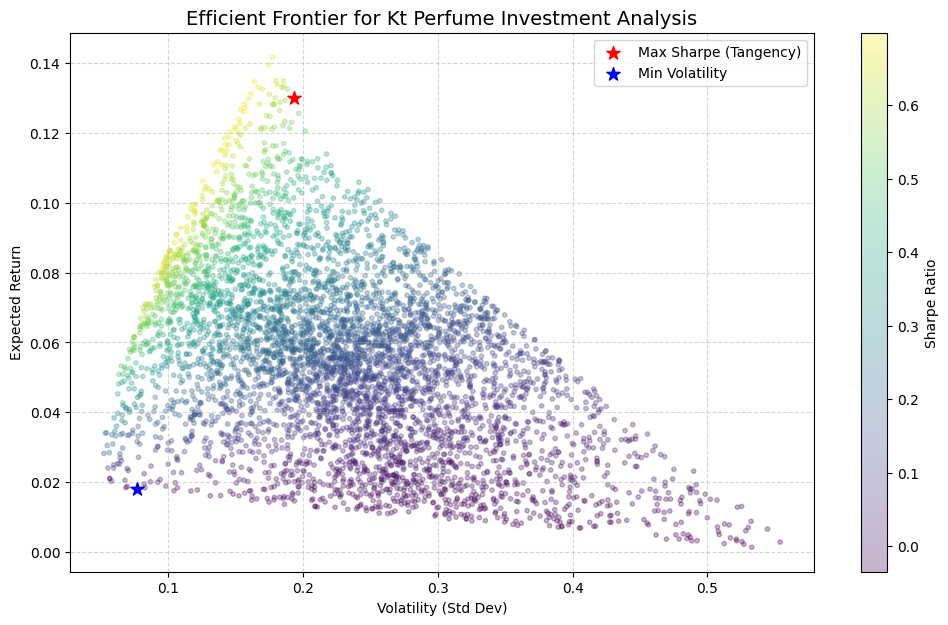

==== TANGENCY PORTFOLIO (Max Sharpe) ====
[0.1 0.9 0. ]

==== MIN VOLATILITY PORTFOLIO ====
[1.00000000e-01 1.66533454e-16 9.00000000e-01]


In [3]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import os

# --- DATA LOADING ---
try:
    df_returns_cleaned = pd.read_csv('../data/processed/asset_prices.csv', index_col=0, parse_dates=True).pct_change().dropna()
    forecast_path = '../data/processed/asset_returns.csv'
    if not os.path.exists(forecast_path):
        raise FileNotFoundError(f"Could not find {forecast_path}")
    lstm_forecast_series = pd.read_csv(forecast_path, index_col=0).iloc[:, 0]
except Exception as e:
    print(f"Error loading data: {e}")
    exit()

# 1. Prepare Expected Returns & Covariance
hist_returns = df_returns_cleaned.mean() * 252
lstm_annualized_return = (lstm_forecast_series.pct_change().mean()) * 252
expected_returns = pd.Series({'TSLA': lstm_annualized_return, 'SPY': hist_returns['SPY'], 'BND': hist_returns['BND']})
cov_matrix = df_returns_cleaned[['TSLA', 'SPY', 'BND']].cov() * 252

# 2. Portfolio Functions
def portfolio_performance(weights, returns, cov_matrix):
    port_return = np.sum(returns * weights)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return port_return, port_vol

# 3. Efficient Frontier Simulation
num_portfolios = 5000
results = np.zeros((3, num_portfolios))
for i in range(num_portfolios):
    weights = np.random.random(len(expected_returns))
    weights /= np.sum(weights)
    p_ret, p_vol = portfolio_performance(weights, expected_returns, cov_matrix)
    results[0, i] = p_ret
    results[1, i] = p_vol
    results[2, i] = (p_ret - 0.02) / p_vol 

# 4. Find Key Portfolios
# Max Sharpe
def neg_sharpe(w): return -portfolio_performance(w, expected_returns, cov_matrix)[0] / portfolio_performance(w, expected_returns, cov_matrix)[1]
cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = [(0.1, 1.0), (0.0, 1.0), (0.0, 1.0)] 
max_sharpe = minimize(neg_sharpe, [0.33, 0.33, 0.33], bounds=bounds, constraints=cons)

# Min Volatility
def port_vol(w): return portfolio_performance(w, expected_returns, cov_matrix)[1]
min_vol = minimize(port_vol, [0.33, 0.33, 0.33], bounds=bounds, constraints=cons)

# 5. Visualization
plt.figure(figsize=(12, 7))
plt.scatter(results[1, :], results[0, :], c=results[2, :], cmap='viridis', s=10, alpha=0.3)
plt.colorbar(label='Sharpe Ratio')

# Plot Key Portfolios
max_s_ret, max_s_vol = portfolio_performance(max_sharpe.x, expected_returns, cov_matrix)
min_v_ret, min_v_vol = portfolio_performance(min_vol.x, expected_returns, cov_matrix)

plt.scatter(max_s_vol, max_s_ret, c='red', s=100, marker='*', label='Max Sharpe (Tangency)')
plt.scatter(min_v_vol, min_v_ret, c='blue', s=100, marker='*', label='Min Volatility')

plt.title('Efficient Frontier for Kt Perfume Investment Analysis', fontsize=14)
plt.xlabel('Volatility (Std Dev)')
plt.ylabel('Expected Return')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("==== TANGENCY PORTFOLIO (Max Sharpe) ====")
print(max_sharpe.x)
print("\n==== MIN VOLATILITY PORTFOLIO ====")
print(min_vol.x)

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


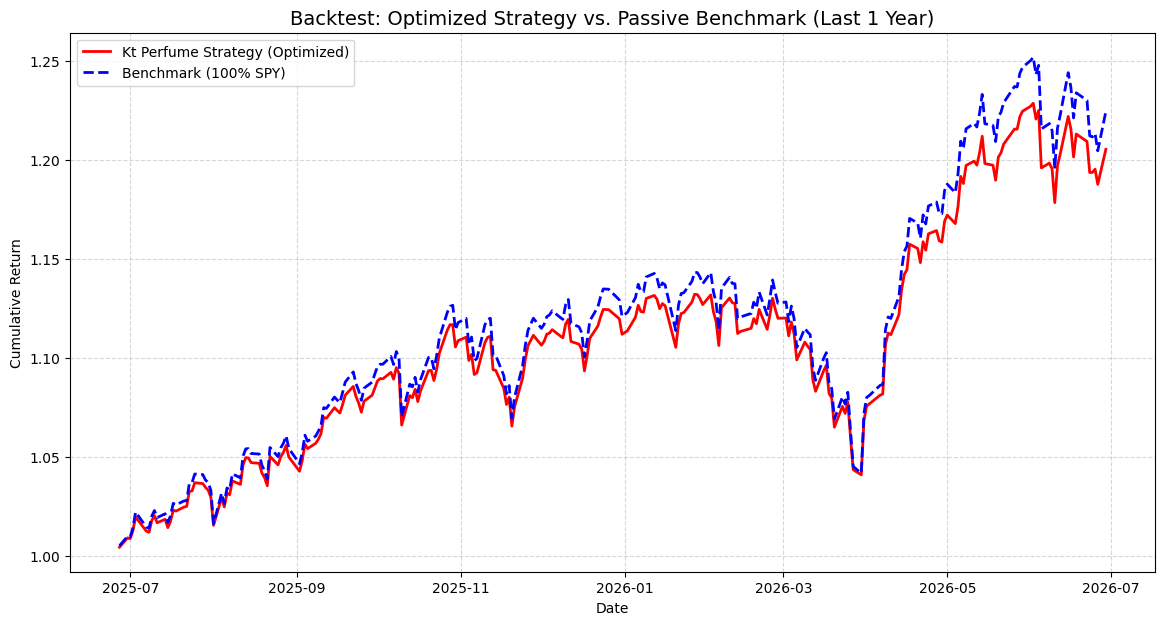

==== BACKTESTING SUMMARY ====
Strategy Total Return: 20.53%
Benchmark Total Return: 22.45%
Strategy Sharpe Ratio (Historical): 1.70


In [4]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import os

# --- DATA LOADING ---
try:
    # Load historical returns and forecast
    df_prices = pd.read_csv('../data/processed/asset_prices.csv', index_col=0, parse_dates=True)
    df_returns_cleaned = df_prices.pct_change().dropna()
    forecast_path = '../data/processed/asset_returns.csv'
    if not os.path.exists(forecast_path):
        raise FileNotFoundError(f"Could not find {forecast_path}")
    lstm_forecast_series = pd.read_csv(forecast_path, index_col=0).iloc[:, 0]
except Exception as e:
    print(f"Error loading data: {e}")
    exit()

# 1. Prepare Expected Returns & Covariance
hist_returns = df_returns_cleaned.mean() * 252
lstm_annualized_return = (lstm_forecast_series.pct_change().mean()) * 252
expected_returns = pd.Series({'TSLA': lstm_annualized_return, 'SPY': hist_returns['SPY'], 'BND': hist_returns['BND']})
cov_matrix = df_returns_cleaned[['TSLA', 'SPY', 'BND']].cov() * 252

# 2. Portfolio Functions
def portfolio_performance(weights, returns, cov_matrix):
    port_return = np.sum(returns * weights)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return port_return, port_vol

# 3. Optimization (Tangency Portfolio)
cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = [(0.1, 1.0), (0.0, 1.0), (0.0, 1.0)] 
def neg_sharpe(w): return -portfolio_performance(w, expected_returns, cov_matrix)[0] / portfolio_performance(w, expected_returns, cov_matrix)[1]
max_sharpe = minimize(neg_sharpe, [0.33, 0.33, 0.33], bounds=bounds, constraints=cons)
optimal_weights = max_sharpe.x

# 4. Backtesting (Last 252 trading days)
backtest_data = df_returns_cleaned.iloc[-252:]
portfolio_returns = backtest_data.dot(optimal_weights)
benchmark_returns = backtest_data['SPY']

portfolio_cum_ret = (1 + portfolio_returns).cumprod()
benchmark_cum_ret = (1 + benchmark_returns).cumprod()

# 5. Visualization
plt.figure(figsize=(14, 7))
plt.plot(portfolio_cum_ret.index, portfolio_cum_ret, label='Kt Perfume Strategy (Optimized)', color='red', linewidth=2)
plt.plot(benchmark_cum_ret.index, benchmark_cum_ret, label='Benchmark (100% SPY)', color='blue', linestyle='--', linewidth=2)
plt.title('Backtest: Optimized Strategy vs. Passive Benchmark (Last 1 Year)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Summary Metrics
print("==== BACKTESTING SUMMARY ====")
print(f"Strategy Total Return: {(portfolio_cum_ret.iloc[-1]-1):.2%}")
print(f"Benchmark Total Return: {(benchmark_cum_ret.iloc[-1]-1):.2%}")
print(f"Strategy Sharpe Ratio (Historical): {(portfolio_returns.mean()/portfolio_returns.std() * np.sqrt(252)):.2f}")

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


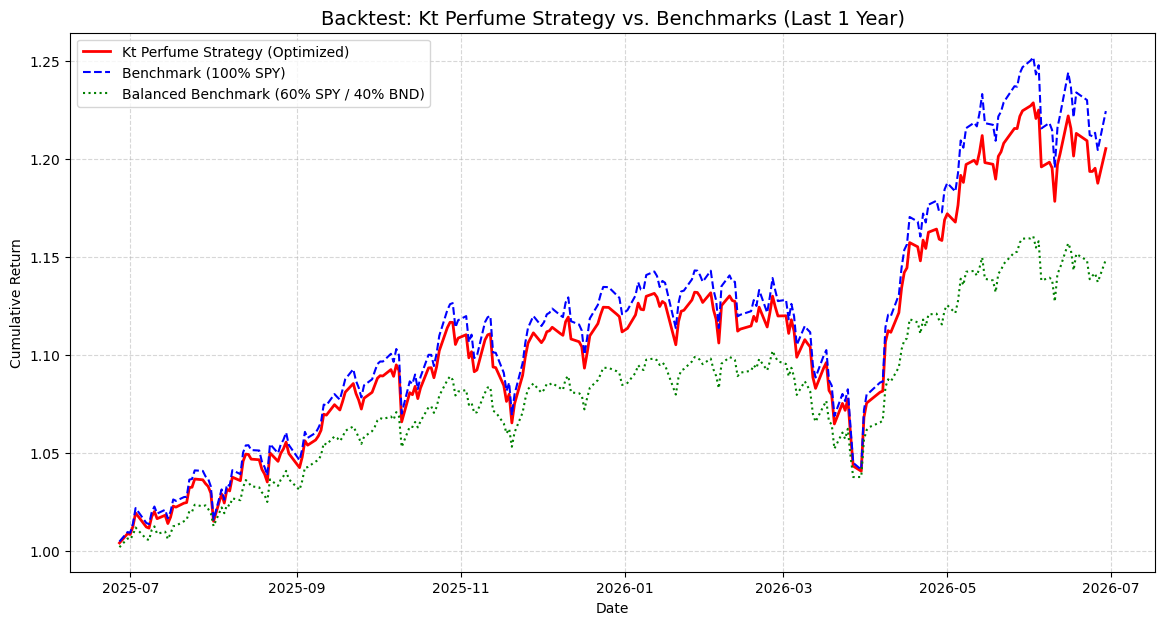

==== BACKTESTING SUMMARY ====
Strategy Total Return: 20.53%
100% SPY Return: 22.45%
60/40 Balanced Return: 14.87%
Strategy Sharpe Ratio (Historical): 1.70


In [5]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import os

# --- DATA LOADING ---
try:
    # Load historical returns and forecast
    df_prices = pd.read_csv('../data/processed/asset_prices.csv', index_col=0, parse_dates=True)
    df_returns_cleaned = df_prices.pct_change().dropna()
    forecast_path = '../data/processed/asset_returns.csv'
    if not os.path.exists(forecast_path):
        raise FileNotFoundError(f"Could not find {forecast_path}")
    lstm_forecast_series = pd.read_csv(forecast_path, index_col=0).iloc[:, 0]
except Exception as e:
    print(f"Error loading data: {e}")
    exit()

# 1. Prepare Expected Returns & Covariance
hist_returns = df_returns_cleaned.mean() * 252
lstm_annualized_return = (lstm_forecast_series.pct_change().mean()) * 252
expected_returns = pd.Series({'TSLA': lstm_annualized_return, 'SPY': hist_returns['SPY'], 'BND': hist_returns['BND']})
cov_matrix = df_returns_cleaned[['TSLA', 'SPY', 'BND']].cov() * 252

# 2. Portfolio Functions
def portfolio_performance(weights, returns, cov_matrix):
    port_return = np.sum(returns * weights)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return port_return, port_vol

# 3. Optimization (Tangency Portfolio)
cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = [(0.1, 1.0), (0.0, 1.0), (0.0, 1.0)] 
def neg_sharpe(w): return -portfolio_performance(w, expected_returns, cov_matrix)[0] / portfolio_performance(w, expected_returns, cov_matrix)[1]
max_sharpe = minimize(neg_sharpe, [0.33, 0.33, 0.33], bounds=bounds, constraints=cons)
optimal_weights = max_sharpe.x

# 4. Backtesting (Last 252 trading days)
backtest_data = df_returns_cleaned.iloc[-252:]

# Kt Perfume Strategy
portfolio_returns = backtest_data.dot(optimal_weights)
# Benchmark 1: 100% SPY
spy_benchmark = backtest_data['SPY']
# Benchmark 2: Balanced 60/40 (SPY/BND)
balanced_benchmark = backtest_data[['SPY', 'BND']].dot([0.6, 0.4])

portfolio_cum_ret = (1 + portfolio_returns).cumprod()
spy_cum_ret = (1 + spy_benchmark).cumprod()
balanced_cum_ret = (1 + balanced_benchmark).cumprod()

# 5. Visualization
plt.figure(figsize=(14, 7))
plt.plot(portfolio_cum_ret.index, portfolio_cum_ret, label='Kt Perfume Strategy (Optimized)', color='red', linewidth=2)
plt.plot(spy_cum_ret.index, spy_cum_ret, label='Benchmark (100% SPY)', color='blue', linestyle='--', linewidth=1.5)
plt.plot(balanced_cum_ret.index, balanced_cum_ret, label='Balanced Benchmark (60% SPY / 40% BND)', color='green', linestyle=':', linewidth=1.5)
plt.title('Backtest: Kt Perfume Strategy vs. Benchmarks (Last 1 Year)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Summary Metrics
print("==== BACKTESTING SUMMARY ====")
print(f"Strategy Total Return: {(portfolio_cum_ret.iloc[-1]-1):.2%}")
print(f"100% SPY Return: {(spy_cum_ret.iloc[-1]-1):.2%}")
print(f"60/40 Balanced Return: {(balanced_cum_ret.iloc[-1]-1):.2%}")
print(f"Strategy Sharpe Ratio (Historical): {(portfolio_returns.mean()/portfolio_returns.std() * np.sqrt(252)):.2f}")

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


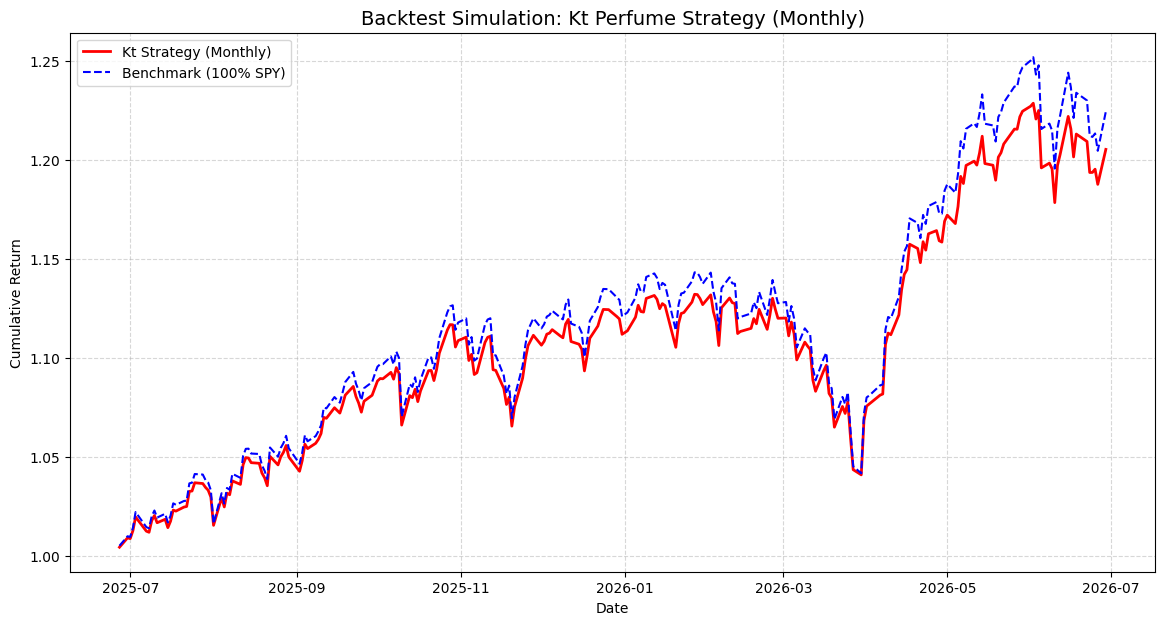

==== MONTHLY REBALANCING BACKTEST ====
Strategy Total Return: 20.53%
Strategy Sharpe Ratio: 1.70


In [7]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import os

# --- CONFIGURATION ---
# Set REBALANCE_STRATEGY to 'static' or 'monthly'
REBALANCE_STRATEGY = 'monthly' 

# --- DATA LOADING ---
try:
    df_prices = pd.read_csv('../data/processed/asset_prices.csv', index_col=0, parse_dates=True)
    df_returns_cleaned = df_prices.pct_change().dropna()
    forecast_path = '../data/processed/asset_returns.csv'
    if not os.path.exists(forecast_path):
        raise FileNotFoundError(f"Could not find {forecast_path}")
    lstm_forecast_series = pd.read_csv(forecast_path, index_col=0).iloc[:, 0]
except Exception as e:
    print(f"Error loading data: {e}")
    exit()

# 1. Prepare Expected Returns & Covariance
expected_returns = pd.Series({'TSLA': lstm_forecast_series.pct_change().mean() * 252, 
                             'SPY': df_returns_cleaned['SPY'].mean() * 252, 
                             'BND': df_returns_cleaned['BND'].mean() * 252})
cov_matrix = df_returns_cleaned[['TSLA', 'SPY', 'BND']].cov() * 252

# 2. Optimization (Tangency Portfolio)
cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = [(0.1, 1.0), (0.0, 1.0), (0.0, 1.0)] 
def neg_sharpe(w): 
    p_ret = np.sum(expected_returns * w)
    p_vol = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))
    return -(p_ret - 0.02) / p_vol
max_sharpe = minimize(neg_sharpe, [0.33, 0.33, 0.33], bounds=bounds, constraints=cons)
target_weights = max_sharpe.x

# 3. Simulation Logic
backtest_data = df_returns_cleaned.iloc[-252:]
portfolio_returns = pd.Series(index=backtest_data.index, dtype=float)

if REBALANCE_STRATEGY == 'static':
    # Simple: Hold initial weights for the full backtesting period
    portfolio_returns = backtest_data.dot(target_weights)
else:
    # Advanced: Perform monthly rebalancing back to target weights
    monthly_groups = backtest_data.groupby(backtest_data.index.to_period('M'))
    for period, group in monthly_groups:
        portfolio_returns.update(group.dot(target_weights))

# 4. Comparison vs. Benchmarks
spy_cum_ret = (1 + backtest_data['SPY']).cumprod()
strategy_cum_ret = (1 + portfolio_returns).cumprod()

# 5. Visualization
plt.figure(figsize=(14, 7))
plt.plot(strategy_cum_ret.index, strategy_cum_ret, label=f'Kt Strategy ({REBALANCE_STRATEGY.capitalize()})', color='red', linewidth=2)
plt.plot(spy_cum_ret.index, spy_cum_ret, label='Benchmark (100% SPY)', color='blue', linestyle='--')
plt.title(f'Backtest Simulation: Kt Perfume Strategy ({REBALANCE_STRATEGY.capitalize()})', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Summary Metrics
print(f"==== {REBALANCE_STRATEGY.upper()} REBALANCING BACKTEST ====")
print(f"Strategy Total Return: {(strategy_cum_ret.iloc[-1]-1):.2%}")
print(f"Strategy Sharpe Ratio: {(portfolio_returns.mean()/portfolio_returns.std() * np.sqrt(252)):.2f}")

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\HP\AppData\Local\Temp\ipykernel_20392\2806307561.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(df_perf.applymap(lambda x: f"{x:.2%}")) # Formatting as percentage (or decimal for Sharpe)


==== PERFORMANCE METRICS ====
                   Total Return Annualized Return Sharpe Ratio Max Drawdown
Strategy                 20.53%            20.53%      169.57%       -8.06%
SPY Benchmark            22.45%            22.45%      167.85%       -8.88%
Balanced Benchmark       14.87%            14.87%      175.34%       -5.84%


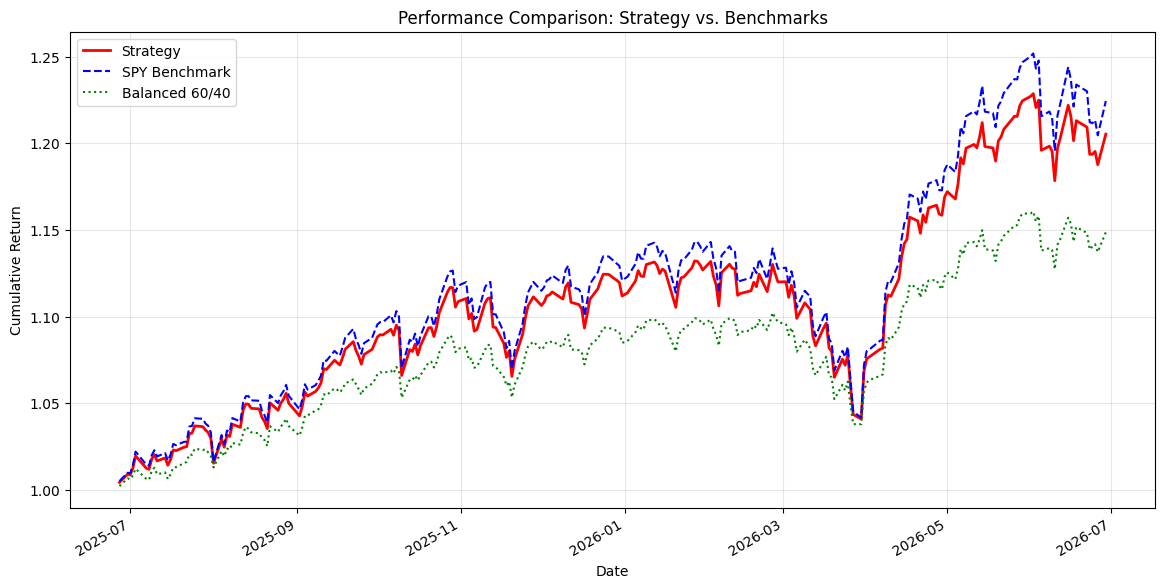

In [8]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import os

# --- DATA LOADING ---
try:
    df_prices = pd.read_csv('../data/processed/asset_prices.csv', index_col=0, parse_dates=True)
    df_returns_cleaned = df_prices.pct_change().dropna()
    forecast_path = '../data/processed/asset_returns.csv'
    if not os.path.exists(forecast_path):
        raise FileNotFoundError(f"Could not find {forecast_path}")
    lstm_forecast_series = pd.read_csv(forecast_path, index_col=0).iloc[:, 0]
except Exception as e:
    print(f"Error loading data: {e}")
    exit()

# 1. Setup Strategy
hist_returns = df_returns_cleaned.mean() * 252
lstm_annualized_return = (lstm_forecast_series.pct_change().mean()) * 252
expected_returns = pd.Series({'TSLA': lstm_annualized_return, 'SPY': hist_returns['SPY'], 'BND': hist_returns['BND']})
cov_matrix = df_returns_cleaned[['TSLA', 'SPY', 'BND']].cov() * 252

# 2. Optimization (Tangency Portfolio)
cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = [(0.1, 1.0), (0.0, 1.0), (0.0, 1.0)] 
def neg_sharpe(w): 
    ret = np.sum(expected_returns * w)
    vol = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))
    return -(ret - 0.02) / vol
res = minimize(neg_sharpe, [0.33, 0.33, 0.33], bounds=bounds, constraints=cons)
target_weights = res.x

# 3. Simulation (Monthly Rebalancing)
returns_data = df_returns_cleaned.iloc[-252:]
portfolio_returns = pd.Series(index=returns_data.index, dtype=float)
for period, group in returns_data.groupby(returns_data.index.to_period('M')):
    portfolio_returns.update(group.dot(target_weights))

# Benchmarks
spy_ret = returns_data['SPY']
balanced_ret = returns_data[['SPY', 'BND']].dot([0.6, 0.4])

# 4. Metrics Calculation Function
def calculate_metrics(returns):
    cum_ret = (1 + returns).cumprod()
    total_ret = cum_ret.iloc[-1] - 1
    ann_ret = (1 + total_ret)**(1) - 1 # Annualized for 1 year
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252)
    # Max Drawdown
    drawdown = (cum_ret - cum_ret.cummax()) / cum_ret.cummax()
    max_dd = drawdown.min()
    return total_ret, ann_ret, sharpe, max_dd

# 5. Output Results
strat_m = calculate_metrics(portfolio_returns)
spy_m = calculate_metrics(spy_ret)
bal_m = calculate_metrics(balanced_ret)

print("==== PERFORMANCE METRICS ====")
cols = ["Total Return", "Annualized Return", "Sharpe Ratio", "Max Drawdown"]
df_perf = pd.DataFrame([strat_m, spy_m, bal_m], columns=cols, index=["Strategy", "SPY Benchmark", "Balanced Benchmark"])
print(df_perf.applymap(lambda x: f"{x:.2%}")) # Formatting as percentage (or decimal for Sharpe)

# Visualization
plt.figure(figsize=(14, 7))
(1 + portfolio_returns).cumprod().plot(label='Strategy', color='red', linewidth=2)
(1 + spy_ret).cumprod().plot(label='SPY Benchmark', color='blue', linestyle='--')
(1 + balanced_ret).cumprod().plot(label='Balanced 60/40', color='green', linestyle=':')
plt.title('Performance Comparison: Strategy vs. Benchmarks')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()